# Quality по методологии MSCI Barra: Россия и Япония

**Автор:** Еремкин Дмитрий Валерьевич  

**Магистерская программа:** «Инвестиции на финансовых рынках», НИУ ВШЭ, 2026

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eremkindv91/dividend-factor-strategies/blob/main/notebooks/02b_quality_barra_msci.ipynb)

---

Реализация фактора качества (Quality) по методологии **MSCI Barra Global Equity Model**. Базовая модель воспроизводит стандартную конструкцию из трёх дескрипторов — ROE, Earnings Variability (волатильность EBITDA за 3 года) и Debt-to-Equity. Авторское расширение дополняет её четырьмя метриками: дивидендная доходность, качество прибыли (accruals, Sloan 1996), генерация свободного денежного потока (FCF Yield) и операционная эффективность (Cash Conversion).

Единая процедура обработки дескрипторов: **Winsorization 5/95 → z-score (cross-sectional per year) → секторная нейтрализация → композит** (NaN-aware среднее доступных z-scores). Далее — квинтильные портфели, регрессия Фамы–Макбета, тест монотонности и межстрановое сравнение рынков РФ и Японии.


In [1]:
# ─── Setup: окружение и пути (Colab / локально) ───
import os, sys, warnings
warnings.filterwarnings('ignore')
from pathlib import Path

if 'google.colab' in sys.modules:
    os.system("pip install -q pandas numpy scipy matplotlib seaborn scikit-learn openpyxl 2>/dev/null")
    REPO_URL = "https://github.com/eremkindv91/dividend-factor-strategies"
    if not os.path.exists("/content/dividend-factor-strategies"):
        os.system(f"git clone {REPO_URL} /content/dividend-factor-strategies 2>/dev/null")
    PROJECT_ROOT = Path("/content/dividend-factor-strategies"); os.chdir(PROJECT_ROOT); sys.path.insert(0, str(PROJECT_ROOT))
    print("Colab environment ready")
else:
    PROJECT_ROOT = Path(os.getcwd()).parent if Path(os.getcwd()).name == "notebooks" else Path(os.getcwd())
    print("Local environment")
DATA_DIR = PROJECT_ROOT / "data"
assert DATA_DIR.exists(), f"data не найдена: {DATA_DIR}"
print("Data:", DATA_DIR)

import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, os, sys
from scipy import stats
from dataclasses import dataclass, field
from typing import Dict, List, Optional
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'figure.dpi': 120,
    'axes.titlesize': 13, 'axes.labelsize': 11, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.max_open_warning': 50,
})

Local environment
Data: /Users/dmitrijeremkin/dividend-factor-strategies/data


## 0. Конфигурация

Пути к панельным данным, ценам и бенчмаркам определяются автоматически
по ключевым словам в директориях проекта. Для РФ ребалансировка
в мае (после публикации годовой отчётности), для Японии — в июле
(после окончания фискального года в марте).

In [2]:
# ═══════════════════════════════════════════════════════════
# 0. CONFIG
# ═══════════════════════════════════════════════════════════

@dataclass
class Config:
    country: str
    panel_path: str
    prices_path: str
    benchmark_path: str
    rf_path: Optional[str]
    ticker_col: str = 'ticker'
    year_col: str = 'year'
    sector_col: str = 'sector'
    rebalance_month: int = 5        # RF=май, JP=июль
    start_year: int = 2012
    max_year: int = 2025
    min_mktcap: float = 5_000       # млн (для Enhanced RF снижаем до 2000)
    tc_bps: float = 50
    benchmark_name: str = 'Benchmark'
    price_format: str = 'wide'      # 'wide' или 'long'
    bm_format: str = 'daily_close'  # daily_close / daily_tr_index

# ── Динамический поиск файлов ──
def find_file(dirs, keyword):
    """Ищет файл по ключевому слову в нескольких директориях."""
    for d in dirs:
        if not os.path.isdir(d): continue
        for f in os.listdir(d):
            if keyword.lower() in f.lower():
                return os.path.join(d, f)
    return None

DIRS = [str(DATA_DIR)]

def _find(kw): return find_file(DIRS, kw)

cfg_rf = Config(
    country='RF',
    panel_path=_find('рф_ПАНЕЛЬ_enriched'),
    prices_path=_find('russian_stocks_adjusted'),
    benchmark_path=_find('мосбиржи'),
    rf_path=_find('руония'),
    sector_col='sector',
    rebalance_month=5,    # май — после выхода РСБУ/МСФО
    min_mktcap=5_000,     # 5 млрд руб
    tc_bps=50,
    benchmark_name='MCFTR',
)

cfg_jp = Config(
    country='JP',
    panel_path=_find('JP_PANEL_enriched'),
    prices_path=_find('nikkei225_monthly_returns'),
    benchmark_path=_find('nikkei225_TR'),
    rf_path=None,         # 3M T-bill захардкожен ниже
    sector_col='super_sector',
    rebalance_month=7,    # июль — после фискального года (март)
    start_year=2012,
    min_mktcap=30_000,    # 30 млрд JPY
    tc_bps=30,
    benchmark_name='Nikkei 225 TR',
    price_format='long',
    bm_format='daily_tr_index',
)

print("Файлы найдены:")
for name, cfg in [('RF', cfg_rf), ('JP', cfg_jp)]:
    for attr in ['panel_path','prices_path','benchmark_path','rf_path']:
        v = getattr(cfg, attr)
        status = '✓' if v and os.path.exists(v) else '✗ NOT FOUND'
        print(f"  {name} {attr:20s}: {status}")

Файлы найдены:
  RF panel_path          : ✓
  RF prices_path         : ✓
  RF benchmark_path      : ✓
  RF rf_path             : ✓
  JP panel_path          : ✓
  JP prices_path         : ✓
  JP benchmark_path      : ✓
  JP rf_path             : ✗ NOT FOUND


## 1. Безрисковые ставки

В качестве безрисковой ставки для России используется RUONIA (ставка
межбанковского рынка overnight), для Японии — доходность 3-месячных
государственных казначейских векселей (Tanki Kokusai). Обе ставки
конвертированы в месячный эквивалент: `r_m = (1 + r_annual)^(1/12) - 1`.
Выбор краткосрочных инструментов обусловлен методологическим
требованием сопоставимости: RUONIA и 3M T-bill — аналоги по дюрации.

In [3]:
# ═══════════════════════════════════════════════════════════
# 1. RISK-FREE RATES
# ═══════════════════════════════════════════════════════════

# Japan 3M T-bill — аналог RUONIA (краткосрочная ставка)
_JP_RF = {
    '2010-01':0.12,'2010-02':0.12,'2010-03':0.13,'2010-04':0.12,'2010-05':0.12,'2010-06':0.11,
    '2010-07':0.11,'2010-08':0.11,'2010-09':0.11,'2010-10':0.11,'2010-11':0.11,'2010-12':0.10,
    '2011-01':0.10,'2011-02':0.10,'2011-03':0.10,'2011-04':0.10,'2011-05':0.10,'2011-06':0.10,
    '2011-07':0.10,'2011-08':0.10,'2011-09':0.10,'2011-10':0.10,'2011-11':0.10,'2011-12':0.10,
    '2012-01':0.10,'2012-02':0.10,'2012-03':0.10,'2012-04':0.10,'2012-05':0.10,'2012-06':0.10,
    '2012-07':0.10,'2012-08':0.10,'2012-09':0.10,'2012-10':0.09,'2012-11':0.09,'2012-12':0.09,
    '2013-01':0.09,'2013-02':0.09,'2013-03':0.08,'2013-04':0.06,'2013-05':0.06,'2013-06':0.06,
    '2013-07':0.06,'2013-08':0.06,'2013-09':0.06,'2013-10':0.06,'2013-11':0.06,'2013-12':0.06,
    '2014-01':0.05,'2014-02':0.05,'2014-03':0.05,'2014-04':0.04,'2014-05':0.04,'2014-06':0.04,
    '2014-07':0.04,'2014-08':0.04,'2014-09':0.03,'2014-10':0.03,'2014-11':0.02,'2014-12':0.02,
    '2015-01':0.02,'2015-02':0.02,'2015-03':0.02,'2015-04':0.01,'2015-05':0.01,'2015-06':0.01,
    '2015-07':0.01,'2015-08':0.01,'2015-09':0.00,'2015-10':0.00,'2015-11':0.00,'2015-12':0.00,
    '2016-01':0.00,'2016-02':-0.05,'2016-03':-0.09,'2016-04':-0.12,'2016-05':-0.14,'2016-06':-0.21,
    '2016-07':-0.24,'2016-08':-0.17,'2016-09':-0.20,'2016-10':-0.17,'2016-11':-0.16,'2016-12':-0.13,
    '2017-01':-0.14,'2017-02':-0.14,'2017-03':-0.13,'2017-04':-0.14,'2017-05':-0.15,'2017-06':-0.14,
    '2017-07':-0.14,'2017-08':-0.14,'2017-09':-0.14,'2017-10':-0.14,'2017-11':-0.14,'2017-12':-0.13,
    '2018-01':-0.14,'2018-02':-0.14,'2018-03':-0.14,'2018-04':-0.13,'2018-05':-0.13,'2018-06':-0.12,
    '2018-07':-0.12,'2018-08':-0.12,'2018-09':-0.12,'2018-10':-0.13,'2018-11':-0.13,'2018-12':-0.14,
    '2019-01':-0.13,'2019-02':-0.12,'2019-03':-0.11,'2019-04':-0.12,'2019-05':-0.12,'2019-06':-0.15,
    '2019-07':-0.16,'2019-08':-0.18,'2019-09':-0.19,'2019-10':-0.16,'2019-11':-0.15,'2019-12':-0.12,
    '2020-01':-0.10,'2020-02':-0.09,'2020-03':-0.05,'2020-04':-0.07,'2020-05':-0.09,'2020-06':-0.10,
    '2020-07':-0.10,'2020-08':-0.10,'2020-09':-0.10,'2020-10':-0.10,'2020-11':-0.11,'2020-12':-0.10,
    '2021-01':-0.10,'2021-02':-0.11,'2021-03':-0.10,'2021-04':-0.10,'2021-05':-0.10,'2021-06':-0.10,
    '2021-07':-0.10,'2021-08':-0.11,'2021-09':-0.10,'2021-10':-0.10,'2021-11':-0.10,'2021-12':-0.10,
    '2022-01':-0.09,'2022-02':-0.08,'2022-03':-0.08,'2022-04':-0.07,'2022-05':-0.06,'2022-06':-0.06,
    '2022-07':-0.08,'2022-08':-0.08,'2022-09':-0.08,'2022-10':-0.06,'2022-11':-0.05,'2022-12':-0.04,
    '2023-01':-0.04,'2023-02':-0.05,'2023-03':-0.07,'2023-04':-0.06,'2023-05':-0.06,'2023-06':-0.05,
    '2023-07':-0.05,'2023-08':-0.03,'2023-09':-0.03,'2023-10':-0.02,'2023-11':-0.02,'2023-12':-0.01,
    '2024-01':-0.02,'2024-02':-0.01,'2024-03':0.00,'2024-04':0.02,'2024-05':0.03,'2024-06':0.04,
    '2024-07':0.05,'2024-08':0.15,'2024-09':0.18,'2024-10':0.20,'2024-11':0.22,'2024-12':0.22,
    '2025-01':0.32,'2025-02':0.42,'2025-03':0.43,'2025-04':0.44,'2025-05':0.46,'2025-06':0.46,
    '2025-07':0.46,'2025-08':0.46,'2025-09':0.46,'2025-10':0.46,'2025-11':0.46,'2025-12':0.46,
}

def build_jp_rf():
    """Japan 3M T-bill → monthly rate."""
    idx = pd.to_datetime(list(_JP_RF.keys())) + pd.offsets.MonthEnd(0)
    annual = np.array(list(_JP_RF.values())) / 100.0
    return pd.Series((1 + annual) ** (1/12) - 1, index=idx, name='rf')

def load_ruonia(path):
    """RUONIA daily → monthly rate."""
    df = pd.read_excel(path)
    dc = df.columns[0]; rc = [c for c in df.columns if c != dc][0]
    df[dc] = pd.to_datetime(df[dc])
    df = df.set_index(dc).sort_index()
    monthly = df[rc].resample('ME').mean()
    return ((1 + monthly / 100) ** (1/12) - 1).rename('rf')

## 2. Вспомогательные функции

Winsorization, z-score нормализация, секторная нейтрализация,
расчёт метрик портфеля и CAPM-alpha с поправкой Newey-West (HAC, 3 лага).

In [4]:
# ═══════════════════════════════════════════════════════════
# 2. HELPERS
# ═══════════════════════════════════════════════════════════

def winz(s, lo=0.05, hi=0.95):
    """Winsorization на уровне lo/hi перцентилей (Barra standard: 5/95)."""
    if s.dropna().shape[0] < 5: return s
    return s.clip(s.quantile(lo), s.quantile(hi))

def zscore(s):
    """Cross-sectional z-score."""
    if s.std() < 1e-10: return s * 0
    return (s - s.mean()) / s.std()

def sector_neutralize(z_series, sectors):
    """
    Секторная нейтрализация по Barra:
    из z-score каждой компании вычитаем среднее по её сектору.
    Результат: within-sector отклонение от средней по сектору.
    """
    df = pd.DataFrame({'z': z_series, 'sec': sectors})
    sec_mean = df.groupby('sec')['z'].transform('mean')
    return df['z'] - sec_mean

def sig_stars(p):
    if pd.isna(p): return ''
    if p < 0.01: return '***'
    if p < 0.05: return '**'
    if p < 0.10: return '*'
    return ''

def metrics(ret, rf=None):
    """Стандартные метрики портфеля."""
    r = ret.dropna()
    if len(r) < 6: return {}
    n = len(r); yrs = n / 12
    cum = (1 + r).prod()
    cagr = cum ** (1 / yrs) - 1 if yrs > 0 else 0
    vol = r.std() * np.sqrt(12)
    if rf is not None:
        rf_m = rf.reindex(r.index).fillna(rf.mean() if len(rf) > 0 else 0)
        excess = r - rf_m
    else:
        excess = r
    sharpe = excess.mean() / excess.std() * np.sqrt(12) if excess.std() > 0 else 0
    down = r[r < 0]
    sortino = excess.mean() / (down.std() * np.sqrt(12)) if len(down) > 1 and down.std() > 0 else np.nan
    dd = (1 + r).cumprod(); maxdd = (dd / dd.cummax() - 1).min()
    hit = (r > 0).mean()
    return {'CAGR': cagr, 'Vol': vol, 'Sharpe': sharpe, 'Sortino': sortino,
            'MaxDD': maxdd, 'HitRate': hit, 'Cumul': cum, 'N_months': n}

def tracking_error(port_ret, bm_ret):
    """Annualised Tracking Error (TE)."""
    c = port_ret.index.intersection(bm_ret.index)
    if len(c) < 12: return np.nan
    diff = port_ret.loc[c] - bm_ret.loc[c]
    return diff.std() * np.sqrt(12)

def capm_alpha(port_ret, bm_ret, rf):
    """CAPM alpha с Newey-West HAC (3 lags)."""
    c = port_ret.index.intersection(bm_ret.index)
    if len(c) < 12: return {}
    rf_c = rf.reindex(c).fillna(rf.mean())
    y = (port_ret.loc[c] - rf_c).values
    x = (bm_ret.loc[c] - rf_c).values
    X = np.column_stack([np.ones(len(c)), x])
    try:
        Xi = np.linalg.inv(X.T @ X)
        b = Xi @ X.T @ y; e = y - X @ b; n = len(c); k = 2; lags = 3
        S = np.zeros((k, k))
        for t in range(n): xt = X[t:t+1].T; S += e[t]**2 * (xt @ xt.T)
        for j in range(1, lags+1):
            w = 1 - j/(lags+1); G = np.zeros((k,k))
            for t in range(j, n): G += e[t]*e[t-j]*(X[t:t+1].T @ X[t-j:t-j+1])
            S += w*(G+G.T)
        cov = Xi @ S @ Xi; se = np.sqrt(np.diag(cov))
        t_a = b[0]/se[0]; p_a = 2*(1-stats.t.cdf(abs(t_a), n-k))
        return {'alpha_m': b[0], 'alpha_ann': b[0]*12, 'beta': b[1],
                't_alpha': t_a, 'p_alpha': p_a, 'sig': sig_stars(p_a)}
    except:
        return {}

## 3. Загрузка данных

Панельные данные (фундаментальные показатели по компаниям), цены и
бенчмарки загружаются из xlsx/csv файлов. Тикеры приводятся к строковому
формату для корректного merge между панелью и ценами. Переменная
`trading_year = year + 1` предотвращает look-ahead bias: фундаментальные
данные за год Y используются для формирования портфелей в году Y+1.

In [5]:
# ═══════════════════════════════════════════════════════════
# 3. DATA LOADER
# ═══════════════════════════════════════════════════════════

class DataLoader:
    def __init__(self, cfg: Config):
        self.cfg = cfg

    def load(self):
        c = self.cfg
        # ── Panel ──
        self.panel = pd.read_excel(c.panel_path)
        self.panel.columns = [col.strip() for col in self.panel.columns]
        self.panel[c.ticker_col] = self.panel[c.ticker_col].astype(str).str.strip()
        self.panel['trading_year'] = self.panel[c.year_col] + 1  # look-ahead bias prevention
        n_tickers = self.panel[c.ticker_col].nunique()
        print(f"\n{'='*60}")
        print(f"  {c.country}: Panel loaded — {len(self.panel)} rows, "
              f"{n_tickers} tickers, {len(self.panel.columns)} cols")

        # ── Prices → long format (date, ticker, ret) ──
        self._load_prices()
        print(f"  Prices: {self.prices[c.ticker_col].nunique()} tickers, "
              f"{self.prices.index.min().date()} → {self.prices.index.max().date()}")

        # ── Benchmark ──
        self._load_benchmark()
        print(f"  Benchmark ({c.benchmark_name}): {len(self.benchmark)} months")

        # ── Rf ──
        if c.rf_path and os.path.exists(c.rf_path):
            self.rf = load_ruonia(c.rf_path)
        else:
            self.rf = build_jp_rf()
        print(f"  Rf: {len(self.rf)} months, avg={self.rf.mean()*12:.2%} ann.")
        print(f"{'='*60}")
        return self

    def _load_prices(self):
        c = self.cfg
        if c.price_format == 'wide':
            raw = pd.read_excel(c.prices_path)
            date_col = [col for col in raw.columns if 'date' in str(col).lower()
                        or 'Unnamed' in str(col)][0]
            raw[date_col] = pd.to_datetime(raw[date_col])
            raw = raw.set_index(date_col).sort_index()
            # wide → long: compute monthly returns
            rets = raw.pct_change()
            rets = rets.stack().reset_index()
            rets.columns = ['date', c.ticker_col, 'ret']
            # clip outliers
            rets['ret'] = rets['ret'].clip(-2, 2)
            rets['date'] = pd.to_datetime(rets['date'])
            rets[c.ticker_col] = rets[c.ticker_col].astype(str).str.strip()
            self.prices = rets.set_index('date').sort_index()
        else:
            # long format (JP: year, date, ticker, return_1mo, ...)
            raw = pd.read_csv(c.prices_path)
            if 'return_1mo' in raw.columns:
                raw = raw.rename(columns={'return_1mo': 'ret'})
            raw['date'] = pd.to_datetime(raw['date'])
            raw['ret'] = raw['ret'].clip(-2, 2)
            raw[c.ticker_col] = raw[c.ticker_col].astype(str).str.strip()
            self.prices = raw.set_index('date')[[c.ticker_col, 'ret']].sort_index()

    def _load_benchmark(self):
        c = self.cfg
        if c.bm_format == 'daily_close':
            # MCFTR CSV: semicolon-delimited, daily close
            raw = pd.read_csv(c.benchmark_path, sep=';', decimal=' ')
            if len(raw.columns) == 1:
                raw = pd.read_csv(c.benchmark_path, sep=';')
            # Parse columns
            if len(raw.columns) == 1:
                # Semicolons in content, try splitting
                expanded = raw.iloc[:, 0].str.split(';', expand=True)
                raw = pd.DataFrame({'ID': expanded[0], 'date': expanded[1],
                                    'open': expanded[2], 'close': expanded[3]})
            cols = raw.columns.tolist()
            date_col = [c for c in cols if 'date' in c.lower() or 'trade' in c.lower()]
            date_col = date_col[0] if date_col else cols[1]
            close_col = [c for c in cols if 'close' in c.lower()]
            close_col = close_col[0] if close_col else cols[-1]
            raw[date_col] = pd.to_datetime(raw[date_col], errors='coerce')
            raw[close_col] = pd.to_numeric(
                raw[close_col].astype(str).str.replace(',', '.').str.replace(' ', ''),
                errors='coerce')
            raw = raw.dropna(subset=[date_col, close_col])
            raw = raw.set_index(date_col).sort_index()
            monthly = raw[close_col].resample('ME').last().dropna()
            self.benchmark = pd.DataFrame({'ret': monthly.pct_change().dropna()})
        else:
            # Nikkei TR Index: daily Date + TR_Index
            raw = pd.read_excel(c.benchmark_path)
            dc = raw.columns[0]; vc = raw.columns[1]
            raw[dc] = pd.to_datetime(raw[dc])
            raw[vc] = pd.to_numeric(raw[vc].astype(str).str.replace(',', '.').str.replace(' ', ''),
                                     errors='coerce')
            raw = raw.dropna(subset=[dc, vc]).set_index(dc).sort_index()
            monthly = raw[vc].resample('ME').last().dropna()
            self.benchmark = pd.DataFrame({'ret': monthly.pct_change().dropna()})

    def get_monthly_returns(self, tickers, year, n_months=12):
        """EW monthly returns for a set of tickers over holding period."""
        c = self.cfg
        start = pd.Timestamp(year, c.rebalance_month, 1)
        rets = []
        for mo in range(n_months):
            dt = start + pd.DateOffset(months=mo)
            mask = ((self.prices.index.year == dt.year) &
                    (self.prices.index.month == dt.month) &
                    self.prices[c.ticker_col].isin(tickers))
            md = self.prices[mask]
            if len(md) > 0:
                mr = md.groupby(c.ticker_col)['ret'].apply(
                    lambda x: (1+x.dropna()).prod()-1 if len(x.dropna())>0 else np.nan
                ).dropna().mean()
                if pd.notna(mr):
                    tc = c.tc_bps / 10000 if mo == 0 else 0
                    rets.append({'date': dt + pd.offsets.MonthEnd(0), 'ret': mr - tc})
        return rets

## 4. Базовый Quality Score (реплика MSCI/Barra)

Базовая модель воспроизводит стандартную конструкцию MSCI Barra Quality
Index, состоящую из трёх дескрипторов:

1. **ROE** — рентабельность собственного капитала (направление: +1)
2. **Earnings Variability** — волатильность EBITDA за 3 года (направление: −1)
3. **D/E** — финансовый рычаг (направление: −1)

Процедура обработки каждого дескриптора:
1. Winsorization на уровне 5/95 перцентилей (cross-sectional per year)
2. Z-score нормализация (μ=0, σ=1 в рамках каждого года)
3. Секторная нейтрализация: z_adj = z − mean(z по сектору компании).
   Это аналог подхода Barra GEM, где факторная экспозиция очищается
   от отраслевого эффекта. Реализация упрощённая (14 секторов для РФ,
   9 для JP) по сравнению с полной моделью Barra (~40 GICS sub-industries).
4. Composite score = NaN-aware mean по доступным дескрипторам.
   Минимум 2 из 3 дескрипторов должны быть non-NaN.

In [6]:
# ═══════════════════════════════════════════════════════════
# 4. QUALITY SCORE (BARRA/MSCI)
# ═══════════════════════════════════════════════════════════

# Barra Quality descriptors: (column_name, direction, candidates)
BARRA_DESCRIPTORS = {
    'ROE':               {'dir': +1, 'candidates': ['roe_pct', 'roa_pct']},
    'EarningsVariability':{'dir': -1, 'candidates': ['vol3y_ebitda', 'vol3y_net_profit']},
    'Leverage':          {'dir': -1, 'candidates': ['debt_to_equity', 'debt_to_ebitda',
                                                     'net_debt_to_ebitda', 'leverage_ratio']},
}

def compute_quality_score(panel, cfg, descriptors=BARRA_DESCRIPTORS):
    """
    Вычисляет Composite Quality Score по методологии Barra.
    Возвращает панель с колонкой 'quality_score'.
    """
    tc = cfg.ticker_col
    sc = cfg.sector_col
    panel = panel.copy()
    panel['quality_score'] = np.nan

    for year in sorted(panel['trading_year'].unique()):
        mask = panel['trading_year'] == year
        uni = panel.loc[mask].copy()
        if len(uni) < 20:
            continue

        # Фильтр по market cap (если доступен)
        if 'market_cap_mln' in uni.columns and cfg.min_mktcap > 0:
            uni = uni[uni['market_cap_mln'] >= cfg.min_mktcap]
        if len(uni) < 15:
            continue

        # NaN-aware composite: DataFrame колонок с z-scores
        frames = {}
        for desc_name, desc_cfg in descriptors.items():
            direction = desc_cfg['dir']
            # Находим первый доступный столбец
            col = None
            for cand in desc_cfg['candidates']:
                if cand in uni.columns and uni[cand].notna().sum() >= 5:
                    col = cand; break
            if col is None:
                continue

            # 1. Winsorization 5/95
            raw = winz(uni[col], lo=0.05, hi=0.95)
            # 2. Z-score cross-sectional
            z = zscore(raw)
            if z.std() < 1e-10:
                continue
            # 3. Секторная нейтрализация
            if sc in uni.columns and uni[sc].notna().sum() > 5:
                z = sector_neutralize(z, uni[sc])
            # 4. Направление (ROE: +1 → выше=лучше, D/E: −1 → ниже=лучше)
            frames[desc_name] = z * direction

        if not frames:
            continue

        # Composite: NaN-aware mean per company (skipna=True)
        # MSCI requirement: minimum 2 out of 3 descriptors must be non-NaN
        score_df = pd.DataFrame(frames, index=uni.index)
        n_valid_desc = score_df.notna().sum(axis=1)
        composite = score_df.mean(axis=1)  # NaN-aware mean
        composite[n_valid_desc < 2] = np.nan  # drop companies with <2 descriptors

        # Записываем обратно в панель
        panel.loc[composite.index, 'quality_score'] = composite

    n_valid = panel['quality_score'].notna().sum()
    n_total = len(panel)
    pct = n_valid / n_total * 100
    print(f"  {cfg.country}: Quality Score computed — "
          f"{n_valid}/{n_total} ({pct:.0f}%) observations")

    # Диагностика: какие дескрипторы использовались
    for desc_name, desc_cfg in descriptors.items():
        for cand in desc_cfg['candidates']:
            if cand in panel.columns and panel[cand].notna().sum() >= 5:
                print(f"    {desc_name:25s} → {cand} "
                      f"(coverage: {panel[cand].notna().sum()}/{n_total})")
                break
        else:
            print(f"    {desc_name:25s} → NOT FOUND")

    return panel

## 5. Квинтильная сортировка и бэктест

Стандартная процедура факторного анализа (Fama & French, 1993):
ежегодно компании ранжируются по Quality Score и распределяются
в 5 равных групп (Q1 = лучшее качество, Q5 = худшее). Для каждого
квинтиля формируется EW-портфель с годовой ребалансировкой.
Транзакционные издержки вычитаются при входе в позицию.

In [7]:
# ═══════════════════════════════════════════════════════════
# 5. QUINTILE ENGINE
# ═══════════════════════════════════════════════════════════

def run_quintile_backtest(dl, n_q=5):
    """
    Quintile sort по quality_score. Q1=лучшее качество, Q5=худшее.
    Ежегодная ребалансировка. EW portfolios.
    Возвращает {q: DataFrame(date, ret)}.
    """
    c = dl.cfg
    panel = dl.panel
    q_rets = {q: [] for q in range(1, n_q + 1)}

    for year in range(c.start_year, c.max_year + 1):
        uni = panel[panel['trading_year'] == year].copy()
        # Фильтр market cap
        if 'market_cap_mln' in uni.columns and c.min_mktcap > 0:
            uni = uni[uni['market_cap_mln'] >= c.min_mktcap]
        uni = uni.dropna(subset=['quality_score'])
        if len(uni) < n_q * 3:
            continue

        # Quintile assignment (1=best quality, 5=worst)
        try:
            uni['_q'] = pd.qcut(uni['quality_score'], n_q, labels=False, duplicates='drop') + 1
            # Reverse: higher score = Q1
            uni['_q'] = n_q + 1 - uni['_q']
        except:
            continue

        for q in range(1, n_q + 1):
            tks = uni[uni['_q'] == q][c.ticker_col].tolist()
            if tks:
                r = dl.get_monthly_returns(tks, year)
                q_rets[q].extend(r)

    results = {}
    for q in range(1, n_q + 1):
        if len(q_rets[q]) >= 12:
            df = pd.DataFrame(q_rets[q]).set_index('date').sort_index()
            df = df.groupby(df.index).mean()
            results[q] = df
    return results

## 6. Расчёт базовой модели для обоих рынков

In [8]:
# ═══════════════════════════════════════════════════════════
# 6. RUN BOTH COUNTRIES
# ═══════════════════════════════════════════════════════════

country_data = {}

for label, cfg in [('RF', cfg_rf), ('JP', cfg_jp)]:
    dl = DataLoader(cfg).load()

    # Вычисляем Quality Score
    dl.panel = compute_quality_score(dl.panel, cfg)

    # Бэктест
    results = run_quintile_backtest(dl)
    print(f"  {label}: Quintiles computed — "
          f"{', '.join(f'Q{q}:{len(results[q])}mo' for q in sorted(results))}")

    country_data[label] = {'cfg': cfg, 'dl': dl, 'results': results}


  RF: Panel loaded — 3048 rows, 268 tickers, 209 cols
  Prices: 287 tickers, 2011-02-28 → 2026-01-31


  Benchmark (MCFTR): 251 months
  Rf: 180 months, avg=8.71% ann.
  RF: Quality Score computed — 1360/3048 (45%) observations
    ROE                       → roe_pct (coverage: 2547/3048)
    EarningsVariability       → vol3y_ebitda (coverage: 1822/3048)
    Leverage                  → debt_to_equity (coverage: 1372/3048)


  RF: Quintiles computed — Q1:165mo, Q2:165mo, Q3:165mo, Q4:165mo, Q5:165mo



  JP: Panel loaded — 3660 rows, 246 tickers, 156 cols
  Prices: 255 tickers, 2009-02-28 → 2026-01-31
  Benchmark (Nikkei 225 TR): 176 months
  Rf: 192 months, avg=0.01% ann.


  JP: Quality Score computed — 3037/3660 (83%) observations
    ROE                       → roe_pct (coverage: 2886/3660)
    EarningsVariability       → vol3y_ebitda (coverage: 2679/3660)
    Leverage                  → debt_to_equity (coverage: 2869/3660)


  JP: Quintiles computed — Q1:163mo, Q2:163mo, Q3:163mo, Q4:163mo, Q5:163mo


## 7. Результаты базовой модели (3 дескриптора)

In [9]:
# ═══════════════════════════════════════════════════════════
# 7. PERFORMANCE TABLES
# ═══════════════════════════════════════════════════════════

for label in ['RF', 'JP']:
    cd = country_data[label]
    dl = cd['dl']; results = cd['results']
    print(f"\n{'='*80}")
    print(f"  {label}: QUALITY FACTOR — QUINTILE PERFORMANCE")
    print(f"{'='*80}")
    print(f"  {'Port':<8} {'CAGR':>8} {'Vol':>8} {'Sharpe':>8} {'Sortino':>8} "
          f"{'MaxDD':>8} {'HitRate':>8} {'Cumul':>8} {'TE':>8} {'Alpha':>8} {'t(α)':>7} {'sig':>4}")
    print(f"  {'─'*100}")

    for q in sorted(results):
        ret = results[q]['ret']
        m = metrics(ret, dl.rf)
        te = tracking_error(ret, dl.benchmark['ret'])
        cap = capm_alpha(ret, dl.benchmark['ret'], dl.rf)
        alp = f"{cap.get('alpha_ann',np.nan):.1%}" if cap else '—'
        ta  = f"{cap.get('t_alpha',np.nan):+.2f}" if cap else '—'
        sig = cap.get('sig', '') if cap else ''
        print(f"  Q{q:<7} {m['CAGR']:>7.1%} {m['Vol']:>7.1%} {m['Sharpe']:>8.2f} "
              f"{m.get('Sortino',np.nan):>8.2f} {m['MaxDD']:>7.1%} "
              f"{m['HitRate']:>7.0%} {m['Cumul']:>7.1f}x {te:>7.1%} "
              f"{alp:>8} {ta:>7} {sig:>4}")

    # L/S Q1−Q5
    if 1 in results and 5 in results:
        c_idx = results[1].index.intersection(results[5].index)
        if len(c_idx) >= 12:
            ls_ret = results[1]['ret'].loc[c_idx] - results[5]['ret'].loc[c_idx]
            m = metrics(ls_ret, dl.rf)
            cap = capm_alpha(ls_ret, dl.benchmark['ret'], dl.rf)
            alp = f"{cap.get('alpha_ann',np.nan):.1%}" if cap else '—'
            ta  = f"{cap.get('t_alpha',np.nan):+.2f}" if cap else '—'
            sig = cap.get('sig', '') if cap else ''
            print(f"  {'─'*100}")
            print(f"  {'L/S':<8} {m['CAGR']:>7.1%} {m['Vol']:>7.1%} {m['Sharpe']:>8.2f} "
                  f"{m.get('Sortino',np.nan):>8.2f} {m['MaxDD']:>7.1%} "
                  f"{m['HitRate']:>7.0%} {'':>8} {'':>8} "
                  f"{alp:>8} {ta:>7} {sig:>4}")

    # Monotonicity check
    cagrs = [metrics(results[q]['ret'])['CAGR'] for q in sorted(results)]
    mono = all(cagrs[i] >= cagrs[i+1] for i in range(len(cagrs)-1))
    print(f"\n  Monotonicity Q1→Q5: {'✓ YES' if mono else '✗ NO'}")
    spread = cagrs[0] - cagrs[-1] if len(cagrs) >= 2 else 0
    print(f"  Q1−Q5 CAGR spread: {spread:.1%}")


  RF: QUALITY FACTOR — QUINTILE PERFORMANCE
  Port         CAGR      Vol   Sharpe  Sortino    MaxDD  HitRate    Cumul       TE    Alpha    t(α)  sig
  ────────────────────────────────────────────────────────────────────────────────────────────────────
  Q1         11.8%   20.3%     0.20     0.02  -42.8%     60%     4.6x   12.6%     0.5%   +0.16     
  Q2         18.6%   21.6%     0.48     0.06  -31.1%     63%    10.5x   13.2%     6.7%   +1.64     
  Q3          9.4%   21.1%     0.10     0.01  -37.8%     62%     3.4x   13.6%    -1.2%   -0.31     
  Q4          5.7%   23.1%    -0.04    -0.00  -45.4%     55%     2.1x   14.4%    -4.8%   -1.25     
  Q5          8.9%   24.8%     0.10     0.01  -44.8%     55%     3.2x   16.3%    -1.5%   -0.35     
  ────────────────────────────────────────────────────────────────────────────────────────────────────
  L/S         0.8%   13.1%    -0.56    -0.07  -47.9%     52%                      -7.1%   -1.95    *

  Monotonicity Q1→Q5: ✗ NO
  Q1−Q5 CAGR sp

## 8. Кумулятивная доходность квинтилей (базовая модель)

Графики кумулятивной доходности Q1–Q5 в сравнении с бенчмарком
на логарифмической шкале. Нижняя панель — drawdown. Красная заливка
отмечает кризисные периоды (Крым, COVID, санкции для РФ; Фукусима,
COVID, кризис йены для Японии).

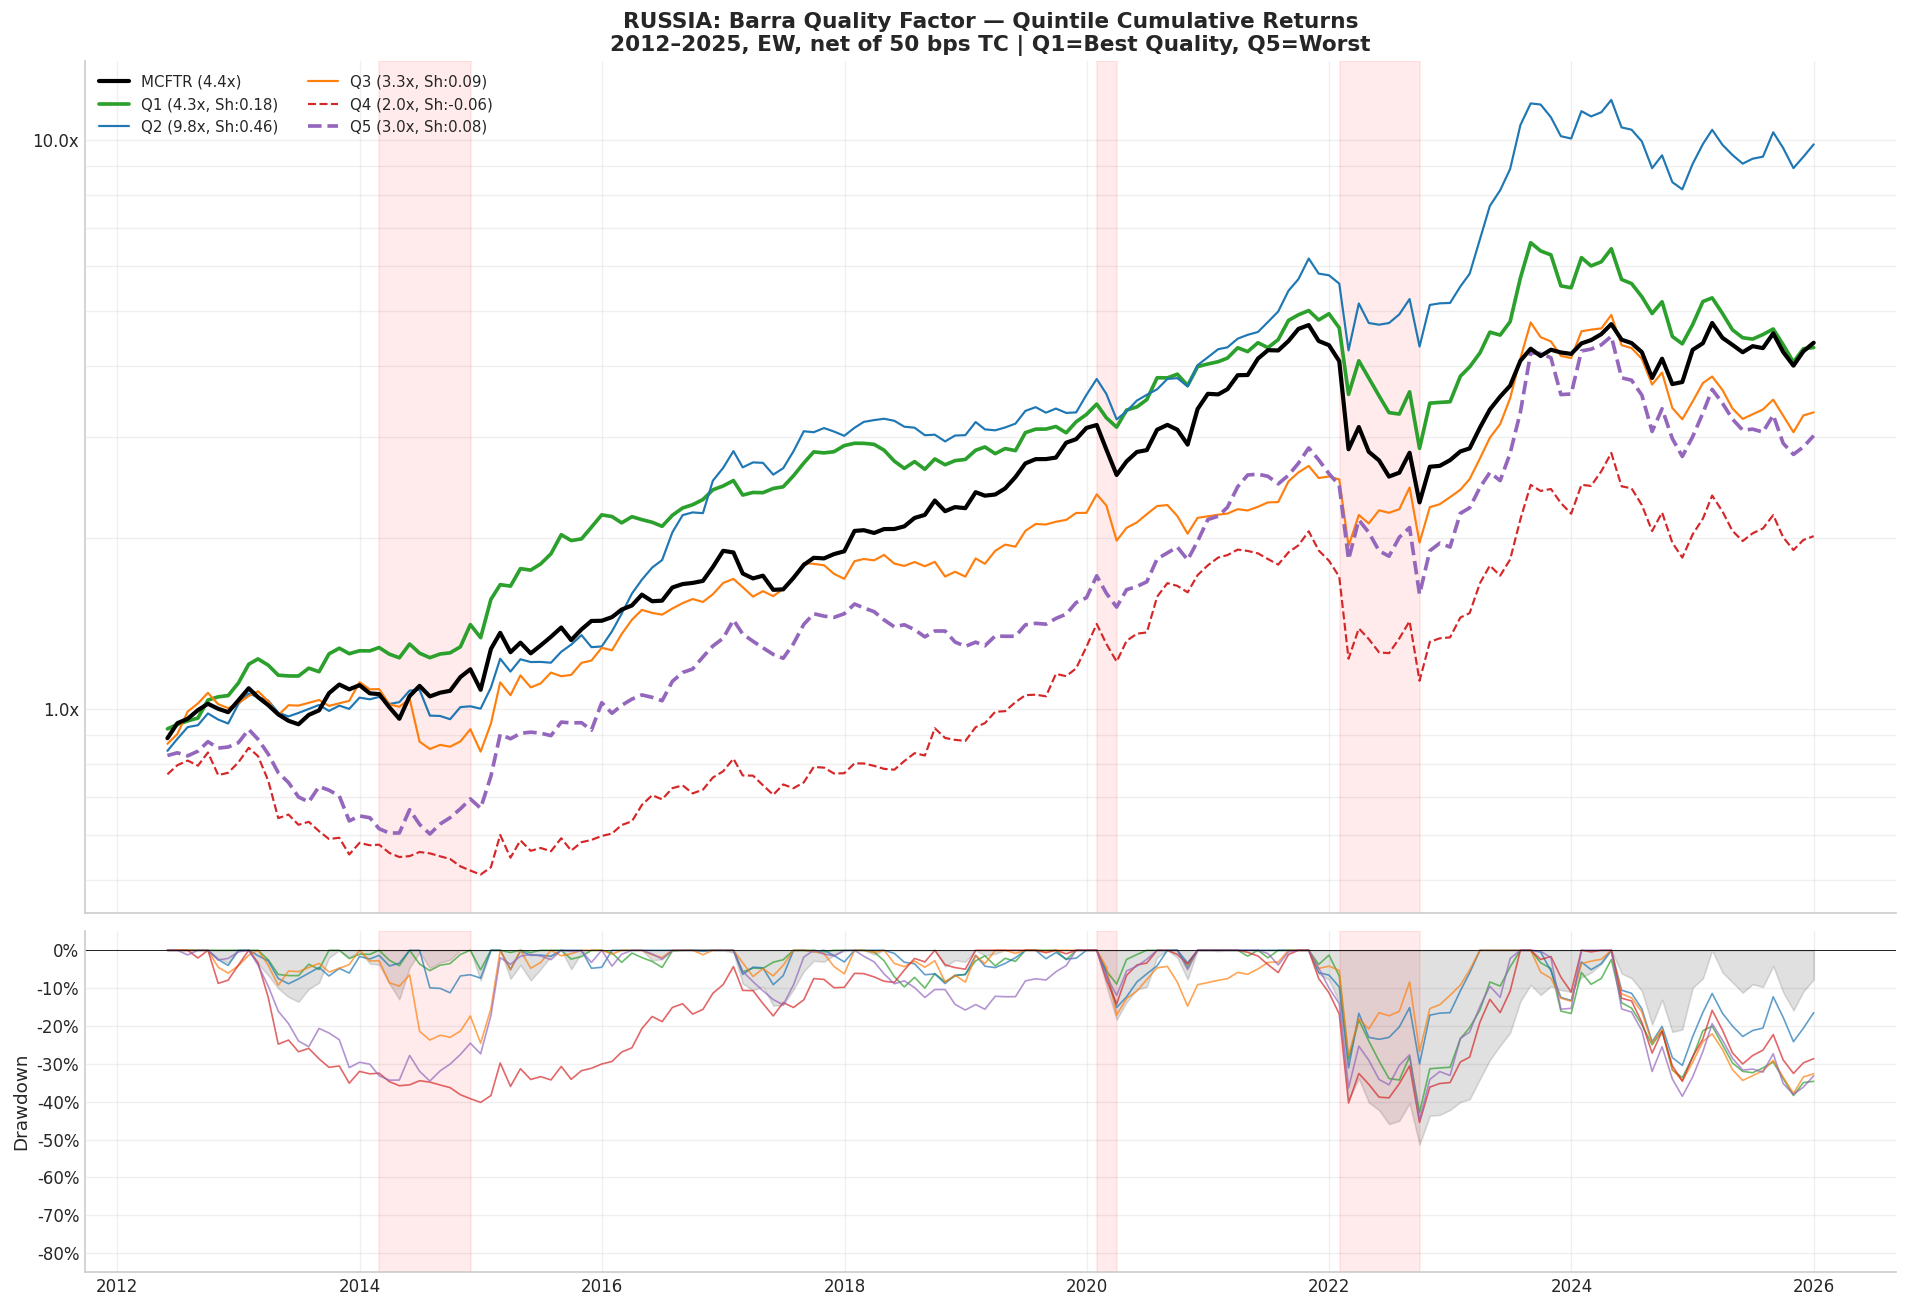

  Saved: /Users/dmitrijeremkin/dividend-factor-strategies/results/quality_barra/barra_quality_RF.png


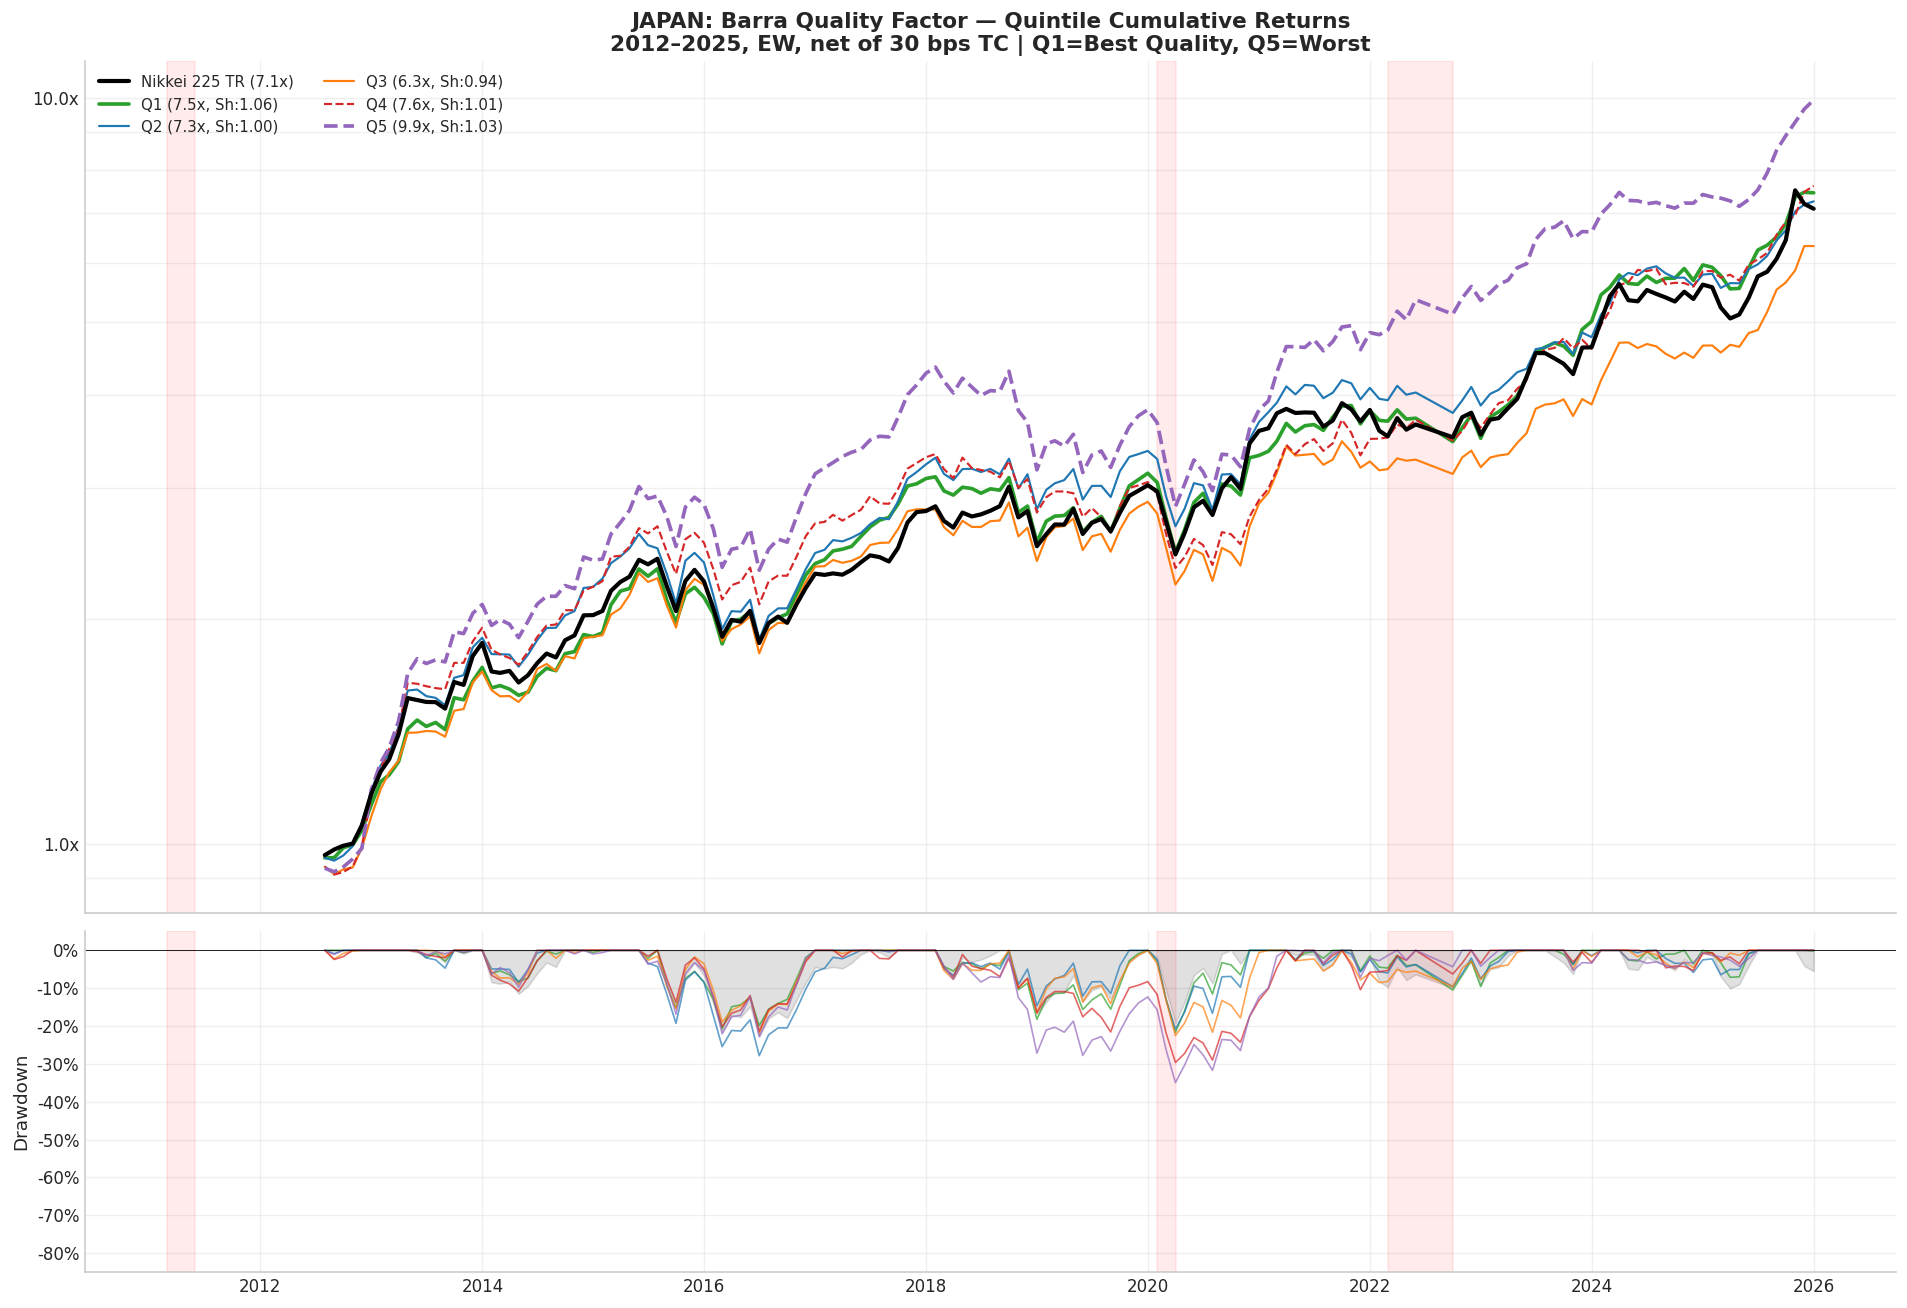

  Saved: /Users/dmitrijeremkin/dividend-factor-strategies/results/quality_barra/barra_quality_JP.png


In [10]:
# ═══════════════════════════════════════════════════════════
# 8. CHARTS
# ═══════════════════════════════════════════════════════════

CRISIS_RF = [('2014-03','2014-12','Crimea/Oil'),
             ('2020-02','2020-04','COVID'),
             ('2022-02','2022-10','Sanctions')]
CRISIS_JP = [('2011-03','2011-06','Fukushima'),
             ('2020-02','2020-04','COVID'),
             ('2022-03','2022-10','Yen Crisis')]
QCOLORS = {1:'#2ca02c', 2:'#1f77b4', 3:'#ff7f0e', 4:'#d62728', 5:'#9467bd'}

OUT = str(PROJECT_ROOT / "results" / "quality_barra")
os.makedirs(OUT, exist_ok=True)

for label in ['RF', 'JP']:
    cd = country_data[label]
    dl = cd['dl']; results = cd['results']
    crises = CRISIS_RF if label == 'RF' else CRISIS_JP

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 11),
                                    height_ratios=[2.5, 1], sharex=True)

    # Benchmark
    forced_start = pd.Timestamp(dl.cfg.start_year, dl.cfg.rebalance_month, 1) \
                   + pd.offsets.MonthEnd(0)
    bm_idx = dl.benchmark.index[dl.benchmark.index >= forced_start]
    if len(bm_idx) > 0:
        bm_cum = (1 + dl.benchmark.loc[bm_idx, 'ret']).cumprod()
        ax1.plot(bm_cum.index, bm_cum.values, 'k-', lw=2.5,
                 label=f"{dl.cfg.benchmark_name} ({bm_cum.iloc[-1]:.1f}x)", zorder=100)
        bm_dd = bm_cum / bm_cum.cummax() - 1
        ax2.fill_between(bm_dd.index, bm_dd.values, 0, color='black', alpha=0.12,
                         label=dl.cfg.benchmark_name)

    for q in sorted(results):
        strat_ret = results[q]['ret'].dropna()
        if len(strat_ret) == 0: continue
        first_date = strat_ret.index.min()
        bm_sub = bm_idx[bm_idx >= first_date] if len(bm_idx) > 0 else strat_ret.index
        ret = strat_ret.reindex(bm_sub).fillna(0)
        cum = (1 + ret).cumprod()
        dd = cum / cum.cummax() - 1
        m = metrics(ret, dl.rf)
        c = QCOLORS.get(q, '#333')
        lw = 2.2 if q in [1, 5] else 1.3
        ls = '-' if q in [1, 2, 3] else '--'
        ax1.plot(cum.index, cum.values, color=c, lw=lw, ls=ls,
                 label=f"Q{q} ({cum.iloc[-1]:.1f}x, Sh:{m['Sharpe']:.2f})")
        ax2.plot(dd.index, dd.values, color=c, lw=1.0, alpha=0.7)

    # Crisis shading
    for s, e, n in crises:
        for ax in [ax1, ax2]:
            ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.08, color='red')

    ax1.set_yscale('log')
    ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x:.1f}x'))
    country_name = 'RUSSIA' if label == 'RF' else 'JAPAN'
    ax1.set_title(f'{country_name}: Barra Quality Factor — Quintile Cumulative Returns\n'
                  f'{dl.cfg.start_year}–{dl.cfg.max_year}, EW, net of {dl.cfg.tc_bps:.0f} bps TC | '
                  f'Q1=Best Quality, Q5=Worst',
                  fontsize=13, fontweight='bold')
    ax1.legend(loc='upper left', fontsize=9, ncol=2, framealpha=0.9)
    ax1.grid(True, alpha=0.3, which='both')
    ax1.tick_params(labelbottom=False)

    ax2.set_ylabel('Drawdown')
    ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x:.0%}'))
    ax2.set_ylim([-0.85, 0.05])
    ax2.grid(True, alpha=0.3)
    ax2.axhline(0, color='black', lw=0.5)

    plt.tight_layout()
    fn = os.path.join(OUT, f'barra_quality_{label}.png')
    plt.savefig(fn, bbox_inches='tight', dpi=180); plt.show()
    print(f"  Saved: {fn}")

## 8b. Валидация: сравнение с индексом MSCI Japan Quality

Для проверки корректности нашей реализации сопоставляем годовые доходности
портфеля Q1 с официальным MSCI Japan IMI Quality Index (данные из factsheet,
JPY, Gross Returns). Также сравниваем с Nikkei 225 Total Return.
Для российского рынка аналогичный индекс отсутствует (MSCI Russia
прекращён в марте 2022).

  JP Q1 vs MSCI Japan IMI Quality: corr = 0.890
  JP Q1 vs Nikkei 225 TR: corr = 0.900

  Annual Returns Comparison (JPY):
  Year       Our Q1   Nikkei 225 TR   MSCI Quality   Q1−Nikkei
  ────────────────────────────────────────────────────────────
  2012       12.8%          25.6%         17.4%     -12.9%
  2013       52.8%          59.3%         45.2%      -6.6%
  2014       10.0%           9.0%         19.1%       1.0%
  2015       12.9%          11.0%         17.2%       1.9%
  2016       11.0%           2.4%         -0.6%       8.6%
  2017       30.0%          21.3%         23.5%       8.7%
  2018      -17.8%         -10.3%        -14.7%      -7.5%
  2019       23.7%          20.7%         25.9%       2.9%
  2020        5.6%          18.3%         20.1%     -12.6%
  2021       14.9%           6.7%         11.8%       8.2%
  2022       -5.0%          -7.3%        -14.2%       2.4%
  2023       43.4%          31.0%         29.6%      12.5%
  2024       19.1%          21.3%         1

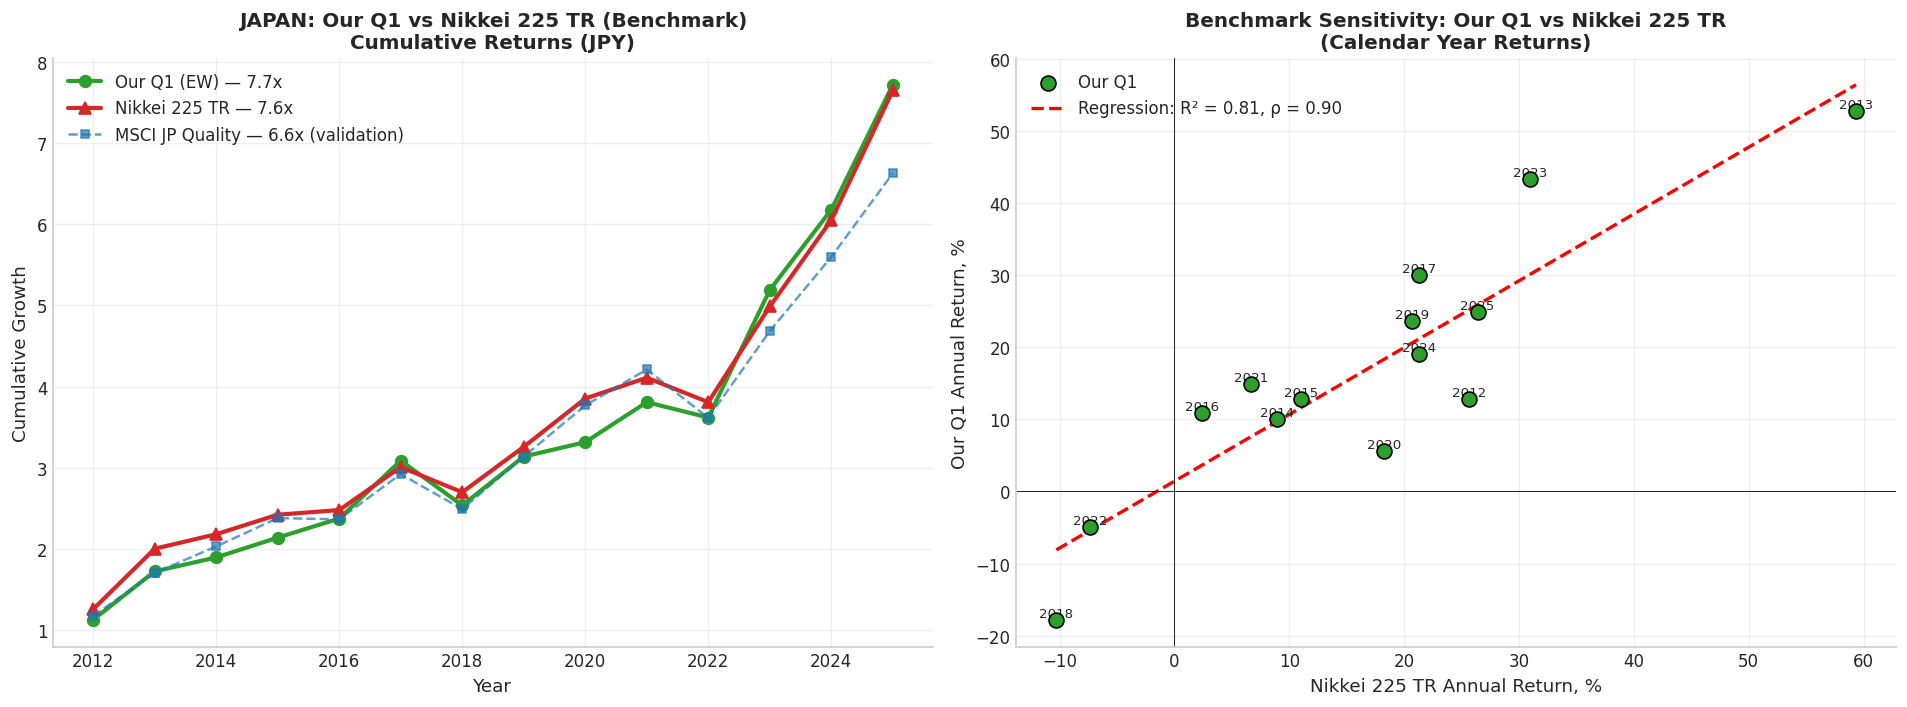


  Saved: /Users/dmitrijeremkin/dividend-factor-strategies/results/quality_barra/jp_q1_vs_nikkei_benchmark.png


In [11]:
# ═══════════════════════════════════════════════════════════
# 8b. MSCI JAPAN QUALITY INDEX COMPARISON
# ═══════════════════════════════════════════════════════════

# MSCI Japan IMI Quality Index — Annual Returns (JPY, Gross)
# Source: MSCI factsheet, Jan 2011 – Jan 2026
_MSCI_JP_QUALITY = {
    2012: 0.1742, 2013: 0.4524, 2014: 0.1906, 2015: 0.1718,
    2016: -0.0061, 2017: 0.2353, 2018: -0.1472, 2019: 0.2590,
    2020: 0.2012, 2021: 0.1175, 2022: -0.1416, 2023: 0.2959,
    2024: 0.1949, 2025: 0.1841,
}
# MSCI Japan IMI (parent) — Annual Returns (JPY, Gross)
_MSCI_JP_PARENT = {
    2012: 0.2106, 2013: 0.5465, 2014: 0.1045, 2015: 0.1122,
    2016: 0.0044, 2017: 0.2137, 2018: -0.1543, 2019: 0.1888,
    2020: 0.0785, 2021: 0.1300, 2022: -0.0310, 2023: 0.2759,
    2024: 0.2035, 2025: 0.2559,
}

if 'JP' in country_data and 1 in country_data['JP']['results']:
    # Our Q1 → calendar year returns
    q1_ret = country_data['JP']['results'][1]['ret']
    our_annual = q1_ret.groupby(q1_ret.index.year).apply(
        lambda x: (1 + x).prod() - 1
    )

    # Nikkei 225 TR → calendar year returns
    bm_ret = country_data['JP']['dl'].benchmark['ret']
    bm_annual = bm_ret.groupby(bm_ret.index.year).apply(
        lambda x: (1 + x).prod() - 1
    )

    # Align years
    common_years = sorted(set(our_annual.index) & set(bm_annual.index) & set(_MSCI_JP_QUALITY.keys()))
    msci_q = pd.Series({y: _MSCI_JP_QUALITY[y] for y in common_years})
    our_q  = our_annual.loc[common_years]
    nikkei = bm_annual.loc[common_years]

    # ── Correlation ──
    corr_msci = our_q.corr(msci_q)
    corr_nikkei = our_q.corr(nikkei)
    print(f"  JP Q1 vs MSCI Japan IMI Quality: corr = {corr_msci:.3f}")
    print(f"  JP Q1 vs Nikkei 225 TR: corr = {corr_nikkei:.3f}")

    # ── Comparison Table ──
    print(f"\n  Annual Returns Comparison (JPY):")
    print(f"  {'Year':<6} {'Our Q1':>10} {'Nikkei 225 TR':>15} {'MSCI Quality':>14} {'Q1−Nikkei':>11}")
    print(f"  {'─'*60}")
    for y in common_years:
        diff = our_q.loc[y] - nikkei.loc[y]
        print(f"  {y:<6} {our_q.loc[y]:>9.1%} {nikkei.loc[y]:>14.1%} {msci_q.loc[y]:>13.1%} {diff:>10.1%}")

    # ── Cumulative Chart ──
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Left: cumulative returns comparison (Our Q1 vs Nikkei 225 TR vs MSCI Quality)
    cum_our = (1 + pd.Series(our_q.values, index=common_years)).cumprod()
    cum_nikkei = (1 + pd.Series(nikkei.values, index=common_years)).cumprod()
    cum_msci_q = (1 + pd.Series(msci_q.values, index=common_years)).cumprod()

    ax1.plot(common_years, cum_our, 'o-', color='#2ca02c', lw=2.5, ms=7,
             label=f'Our Q1 (EW) — {cum_our.iloc[-1]:.1f}x')
    ax1.plot(common_years, cum_nikkei, '^-', color='#d62728', lw=2.5, ms=7,
             label=f'Nikkei 225 TR — {cum_nikkei.iloc[-1]:.1f}x')
    ax1.plot(common_years, cum_msci_q, 's--', color='#1f77b4', lw=1.5, ms=5, alpha=0.7,
             label=f'MSCI JP Quality — {cum_msci_q.iloc[-1]:.1f}x (validation)')
    ax1.set_title('JAPAN: Our Q1 vs Nikkei 225 TR (Benchmark)\nCumulative Returns (JPY)',
                   fontweight='bold', fontsize=12)
    ax1.set_ylabel('Cumulative Growth')
    ax1.set_xlabel('Year')
    ax1.legend(loc='upper left', fontsize=10)
    ax1.grid(True, alpha=0.3)

    # Right: scatter plot (Our Q1 vs Nikkei)
    ax2.scatter(nikkei.values * 100, our_q.values * 100, s=80, c='#2ca02c',
                edgecolor='black', lw=1, zorder=5, label='Our Q1')
    for y in common_years:
        ax2.annotate(str(y), (nikkei.loc[y]*100, our_q.loc[y]*100),
                     fontsize=8, ha='center', va='bottom')
    # Regression line
    slope, intercept, r_val, _, _ = stats.linregress(nikkei.values, our_q.values)
    x_fit = np.linspace(nikkei.min(), nikkei.max(), 50)
    ax2.plot(x_fit*100, (slope*x_fit + intercept)*100, 'r--', lw=2,
             label=f'Regression: R² = {r_val**2:.2f}, ρ = {corr_nikkei:.2f}')
    ax2.set_xlabel('Nikkei 225 TR Annual Return, %')
    ax2.set_ylabel('Our Q1 Annual Return, %')
    ax2.set_title('Benchmark Sensitivity: Our Q1 vs Nikkei 225 TR\n(Calendar Year Returns)',
                   fontweight='bold', fontsize=12)
    ax2.legend(fontsize=10, loc='upper left')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(0, color='black', lw=0.5); ax2.axvline(0, color='black', lw=0.5)

    plt.tight_layout()
    fn = os.path.join(OUT, 'jp_q1_vs_nikkei_benchmark.png')
    plt.savefig(fn, bbox_inches='tight', dpi=180); plt.show()
    print(f"\n  Saved: {fn}")
else:
    print("  JP data not available for MSCI comparison.")

## 8c. Расширенная модель качества (7 дескрипторов)

Базовая модель MSCI Barra из 3 дескрипторов показала неустойчивые
результаты: на российском рынке Q2 доминирует над Q1, на японском —
обратная монотонность (Q5 > Q1). Возможные причины:
неполное покрытие данных (D/E: ~40% в РФ), малый размер квинтилей
(~20 компаний при пороге 5 млрд руб) и NaN-шум при оценке
по 1 из 3 дескрипторов.

Расширенная модель дополняет базовые три дескриптора четырьмя
метриками, имеющими самостоятельное академическое обоснование.
Дескриптор Payout Ratio исключён из финальной спецификации ввиду
высокой корреляции с Dividend Yield (ρ = 0.73 в РФ), что
нарушало бы требование информационной ненаправленности компонентов
композитного скора.

### Адаптация для российского рынка

Порог по капитализации снижен до 2 млрд руб (vs 5 млрд в базовой
модели). Это увеличивает вселенную до 130–180 компаний в год и
обеспечивает 26–36 компаний на квинтиль, что повышает статистическую
устойчивость результатов. Порог в 2 млрд руб примерно соответствует
среднедневному обороту ≥10 млн руб — достаточно для практического
формирования портфеля. Минимальное число дескрипторов — 4 из 7,
с учётом неполноты раскрытия информации эмитентами MOEX.

### Адаптация для японского рынка

Порог по капитализации — 30 млрд JPY (без изменений). Вместо
чистой дивидендной доходности используется Total Shareholder Yield
(дивиденды + buyback), что учитывает программы обратного выкупа,
ставшие нормой после ревизии Tokyo Stock Exchange Corporate
Governance Code в 2023. Минимум 5 из 7 дескрипторов.

### Состав расширенной модели

| # | Дескриптор | Напр. | Источник |
|---|-----------|-------|----------|
| 1 | ROE | +1 | Barra standard |
| 2 | Earnings Variability | −1 | Barra standard |
| 3 | D/E (Leverage) | −1 | Barra standard |
| 4 | Dividend Yield | +1 | Авт.: дивидендная дисциплина |
| 5 | Accruals Quality | −1 | Авт.: качество прибыли (Sloan, 1996) |
| 6 | FCF Yield | +1 | Авт.: генерация денежного потока |
| 7 | Cash Conversion | +1 | Авт.: операционная эффективность |

In [12]:
# ═══════════════════════════════════════════════════════════
# 8c. АВТОРСКИЙ ИНДЕКС КАЧЕСТВА (Enhanced Barra Quality)
# ═══════════════════════════════════════════════════════════
#
# Методология:
# 1. Cross-sectional Winsorization 5/95 (Barra standard)
# 2. Z-score нормализация (μ=0, σ=1 per year)
# 3. Секторная нейтрализация: z_adj = z − mean(z по сектору)
#    → убирает секторный bias (нефтянка vs IT имеют разный "нормальный" D/E)
# 4. Composite = NaN-aware mean по всем доступным дескрипторам
# 5. Фильтр: компания должна иметь min_desc из 7 дескрипторов
# 6. Quintile sort: Q1 = лучшее качество, Q5 = худшее
# ═══════════════════════════════════════════════════════════

ENHANCED_DESCRIPTORS = {
    # ── Базовые (Barra/MSCI Standard) ──
    'ROE': {
        'dir': +1,
        'candidates': ['roe_pct'],  # строго ROE, без fallback на ROA (разные метрики)
        'comment': 'Profitability — выше ROE = более прибыльный бизнес'
    },
    'EarningsVariability': {
        'dir': -1,
        'candidates': ['vol3y_ebitda', 'vol3y_net_profit'],
        'comment': 'Stability — ниже волатильность EBITDA = стабильнее бизнес'
    },
    'Leverage': {
        'dir': -1,
        'candidates': ['debt_to_equity', 'net_debt_to_ebitda', 'debt_to_ebitda'],
        'comment': 'Financial Safety — ниже D/E = безопаснее баланс'
    },
    # ── Авторские дескрипторы ──
    'DividendYield': {
        'dir': +1,
        'candidates': ['total_shareholder_yield_pct', 'div_yield_pct'],
        'comment': 'Shareholder Return — дивиденды + buyback (JP) / чистые дивиденды (RF)'
    },
    'AccrualsQuality': {
        'dir': -1,
        'candidates': ['accruals_ratio'],
        'comment': 'Earnings Quality (Sloan 1996) — ниже accruals = прибыль подтверждена кэшем'
    },
    'FCFYield': {
        'dir': +1,
        'candidates': ['fcf_yield_pct'],
        'comment': 'Cash Generation — выше FCF yield = больше свободного денежного потока'
    },
    'CashConversion': {
        'dir': +1,
        'candidates': ['cash_conversion'],
        'comment': 'Operational Efficiency — CFO/EBITDA, выше = эффективнее конвертация прибыли в кэш'
    },
    # PayoutRatio исключён: корреляция с DividendYield = 0.73 (РФ)
}
# Итого: 7 дескрипторов (3 базовых Barra + 4 авторских)

# Страновые настройки Enhanced Quality
ENHANCED_CFG = {
    'RF': {
        'min_mktcap': 2_000,       # 2 млрд руб — расширяем вселенную
        'min_desc': 4,              # минимум 4 из 7 дескрипторов (данные РФ неполные)
        'label': 'Расширенная модель качества (РФ, 7 дескрипторов)'
    },
    'JP': {
        'min_mktcap': 30_000,      # 30 млрд JPY — без изменений
        'min_desc': 5,              # минимум 5 из 7 (данные JP более полные)
        'label': 'Расширенная модель качества (JP, 7 дескрипторов)'
    },
}


def compute_enhanced_quality(panel, cfg, descriptors=ENHANCED_DESCRIPTORS,
                              min_mktcap_override=None, min_desc=4):
    """
    Авторский расширенный Quality Score (7 дескрипторов).

    Процедура для каждого cross-section (trading_year):
      1. Фильтр по market cap (страновой порог)
      2. Для каждого дескриптора: Winsorize → Z-score → Sector Neutralize → Direction
      3. NaN-aware composite = mean(доступных z-scores)
      4. Отсеять компании с < min_desc дескрипторов

    Parameters
    ----------
    panel : DataFrame с trading_year, ticker, sector, фундаментальные колонки
    cfg : Config (country, ticker_col, sector_col, etc.)
    min_mktcap_override : float, если задан — используется вместо cfg.min_mktcap
    min_desc : int, минимальное количество non-NaN дескрипторов (RF=4, JP=5)

    Returns
    -------
    panel с новой колонкой 'quality_score_enhanced'
    """
    tc = cfg.ticker_col
    sc = cfg.sector_col
    mktcap_thresh = min_mktcap_override if min_mktcap_override else cfg.min_mktcap
    panel = panel.copy()
    panel['quality_score_enhanced'] = np.nan

    desc_usage = {}  # трекинг: какие дескрипторы реально используются

    for year in sorted(panel['trading_year'].unique()):
        mask = panel['trading_year'] == year
        uni = panel.loc[mask].copy()
        if len(uni) < 20:
            continue

        # Фильтр по market cap
        if 'market_cap_mln' in uni.columns and mktcap_thresh > 0:
            uni = uni[uni['market_cap_mln'] >= mktcap_thresh]
        if len(uni) < 15:
            continue

        frames = {}
        for desc_name, desc_cfg in descriptors.items():
            direction = desc_cfg['dir']
            # Находим первый доступный столбец с достаточным покрытием
            col = None
            for cand in desc_cfg['candidates']:
                if cand in uni.columns and uni[cand].notna().sum() >= 5:
                    col = cand
                    break
            if col is None:
                continue

            # 1. Winsorization 5/95 (Barra standard)
            raw = winz(uni[col], lo=0.05, hi=0.95)
            # 2. Z-score (cross-sectional, per year)
            z = zscore(raw)
            if z.std() < 1e-10:
                continue
            # 3. Секторная нейтрализация
            if sc in uni.columns and uni[sc].notna().sum() > 5:
                z = sector_neutralize(z, uni[sc])
            # 4. Применяем направление
            frames[desc_name] = z * direction

            # Трекинг
            if desc_name not in desc_usage:
                desc_usage[desc_name] = col

        if len(frames) < 3:  # слишком мало дескрипторов в этом году
            continue

        # 5. Composite: NaN-aware mean
        score_df = pd.DataFrame(frames, index=uni.index)
        n_valid = score_df.notna().sum(axis=1)
        composite = score_df.mean(axis=1)

        # 6. Фильтр: отсекаем компании с < min_desc дескрипторов
        composite[n_valid < min_desc] = np.nan

        panel.loc[composite.index, 'quality_score_enhanced'] = composite

    # Диагностика
    n_valid_total = panel['quality_score_enhanced'].notna().sum()
    n_total = len(panel)
    pct = n_valid_total / n_total * 100
    enh_cfg = ENHANCED_CFG.get(cfg.country, {})
    label = enh_cfg.get('label', 'Enhanced Quality')
    print(f"\n  {cfg.country}: {label}")
    print(f"  Score computed — {n_valid_total}/{n_total} ({pct:.0f}%) observations")
    print(f"  Market cap threshold: {mktcap_thresh:,.0f} mln | Min descriptors: {min_desc}/7")
    print(f"  Дескрипторы использованы:")
    for desc_name, desc_cfg in descriptors.items():
        col = desc_usage.get(desc_name, None)
        if col:
            cov = panel[col].notna().sum()
            print(f"    {desc_name:25s} → {col:30s} (dir={desc_cfg['dir']:+d}, "
                  f"coverage={cov}/{n_total}, comment: {desc_cfg.get('comment','')})")
        else:
            print(f"    {desc_name:25s} → NOT FOUND")

    return panel


def run_enhanced_backtest(dl, score_col='quality_score_enhanced',
                           min_mktcap_override=None, n_q=5):
    """
    Quintile backtest по Enhanced Quality Score.
    Аналогично базовому, но с отдельным порогом mktcap.
    """
    c = dl.cfg
    mktcap = min_mktcap_override if min_mktcap_override else c.min_mktcap
    q_rets = {q: [] for q in range(1, n_q + 1)}

    for year in range(c.start_year, c.max_year + 1):
        uni = dl.panel[dl.panel['trading_year'] == year].copy()
        if 'market_cap_mln' in uni.columns and mktcap > 0:
            uni = uni[uni['market_cap_mln'] >= mktcap]
        uni = uni.dropna(subset=[score_col])
        if len(uni) < n_q * 3:
            continue

        try:
            uni['_q'] = pd.qcut(uni[score_col], n_q, labels=False, duplicates='drop') + 1
            uni['_q'] = n_q + 1 - uni['_q']  # higher score = Q1
        except:
            continue

        for q in range(1, n_q + 1):
            tks = uni[uni['_q'] == q][c.ticker_col].tolist()
            if tks:
                r = dl.get_monthly_returns(tks, year)
                q_rets[q].extend(r)

    results = {}
    for q in range(1, n_q + 1):
        if len(q_rets[q]) >= 12:
            df = pd.DataFrame(q_rets[q]).set_index('date').sort_index()
            df = df.groupby(df.index).mean()
            results[q] = df
    return results


# ── Вычисляем Enhanced Quality и бэктест для обеих стран ──
enhanced_data = {}

for label, cfg in [('RF', cfg_rf), ('JP', cfg_jp)]:
    cd = country_data[label]
    dl = cd['dl']
    enh_cfg = ENHANCED_CFG[label]

    # Вычисляем Enhanced Quality Score
    dl.panel = compute_enhanced_quality(
        dl.panel, cfg,
        min_mktcap_override=enh_cfg['min_mktcap'],
        min_desc=enh_cfg['min_desc']
    )

    # Бэктест с Enhanced Score (и Enhanced mktcap threshold)
    results_enh = run_enhanced_backtest(
        dl, score_col='quality_score_enhanced',
        min_mktcap_override=enh_cfg['min_mktcap']
    )

    if results_enh:
        print(f"  Quintiles: {', '.join(f'Q{q}:{len(results_enh[q])}mo' for q in sorted(results_enh))}")
    else:
        print(f"  WARNING: No quintile results for {label} Enhanced!")

    enhanced_data[label] = {'results': results_enh, 'enh_cfg': enh_cfg}


# ── Performance Table: Enhanced Quality ──
for label in ['RF', 'JP']:
    cd = country_data[label]
    dl = cd['dl']
    results_enh = enhanced_data[label]['results']
    enh_cfg = enhanced_data[label]['enh_cfg']

    print(f"\n{'='*90}")
    print(f"  {label}: {enh_cfg['label']} — QUINTILE PERFORMANCE")
    print(f"  Market cap ≥ {enh_cfg['min_mktcap']:,.0f} mln | Min descriptors: {enh_cfg['min_desc']}/7")
    print(f"{'='*90}")
    print(f"  {'Port':<8} {'CAGR':>8} {'Vol':>8} {'Sharpe':>8} {'Sortino':>8} "
          f"{'MaxDD':>8} {'HitRate':>8} {'Cumul':>8} {'TE':>8} {'Alpha':>8} {'t(α)':>7} {'sig':>4}")
    print(f"  {'─'*100}")

    for q in sorted(results_enh):
        ret = results_enh[q]['ret']
        m = metrics(ret, dl.rf)
        te = tracking_error(ret, dl.benchmark['ret'])
        cap = capm_alpha(ret, dl.benchmark['ret'], dl.rf)
        alp = f"{cap.get('alpha_ann',np.nan):.1%}" if cap else '—'
        ta  = f"{cap.get('t_alpha',np.nan):+.2f}" if cap else '—'
        sig_s = cap.get('sig', '') if cap else ''
        print(f"  Q{q:<7} {m['CAGR']:>7.1%} {m['Vol']:>7.1%} {m['Sharpe']:>8.2f} "
              f"{m.get('Sortino',np.nan):>8.2f} {m['MaxDD']:>7.1%} "
              f"{m['HitRate']:>7.0%} {m['Cumul']:>7.1f}x {te:>7.1%} "
              f"{alp:>8} {ta:>7} {sig_s:>4}")

    # L/S
    if 1 in results_enh and 5 in results_enh:
        c_idx = results_enh[1].index.intersection(results_enh[5].index)
        if len(c_idx) >= 12:
            ls_ret = results_enh[1]['ret'].loc[c_idx] - results_enh[5]['ret'].loc[c_idx]
            m = metrics(ls_ret, dl.rf)
            cap = capm_alpha(ls_ret, dl.benchmark['ret'], dl.rf)
            alp = f"{cap.get('alpha_ann',np.nan):.1%}" if cap else '—'
            ta  = f"{cap.get('t_alpha',np.nan):+.2f}" if cap else '—'
            sig_s = cap.get('sig', '') if cap else ''
            print(f"  {'─'*100}")
            print(f"  {'L/S':<8} {m['CAGR']:>7.1%} {m['Vol']:>7.1%} {m['Sharpe']:>8.2f} "
                  f"{m.get('Sortino',np.nan):>8.2f} {m['MaxDD']:>7.1%} "
                  f"{m['HitRate']:>7.0%} {'':>8} {'':>8} "
                  f"{alp:>8} {ta:>7} {sig_s:>4}")

    # Monotonicity
    cagrs_enh = [metrics(results_enh[q]['ret'])['CAGR'] for q in sorted(results_enh)]
    mono = all(cagrs_enh[i] >= cagrs_enh[i+1] for i in range(len(cagrs_enh)-1))
    print(f"\n  Monotonicity Q1→Q5: {'YES' if mono else 'NO'}")
    spread = cagrs_enh[0] - cagrs_enh[-1] if len(cagrs_enh) >= 2 else 0
    print(f"  Q1-Q5 CAGR spread: {spread:.1%}")

    # Сравнение с базовым
    base_res = cd['results']
    if 1 in base_res and 1 in results_enh:
        m_base = metrics(base_res[1]['ret'], dl.rf)
        m_enh = metrics(results_enh[1]['ret'], dl.rf)
        print(f"\n  Base Q1:     CAGR={m_base['CAGR']:.1%}, Sharpe={m_base['Sharpe']:.2f}")
        print(f"  Enhanced Q1: CAGR={m_enh['CAGR']:.1%}, Sharpe={m_enh['Sharpe']:.2f}")
        diff_sh = m_enh['Sharpe'] - m_base['Sharpe']
        print(f"  Sharpe improvement: {diff_sh:+.2f}")


  RF: Расширенная модель качества (РФ, 7 дескрипторов)
  Score computed — 1594/3048 (52%) observations
  Market cap threshold: 2,000 mln | Min descriptors: 4/7
  Дескрипторы использованы:
    ROE                       → roe_pct                        (dir=+1, coverage=2547/3048, comment: Profitability — выше ROE = более прибыльный бизнес)
    EarningsVariability       → vol3y_ebitda                   (dir=-1, coverage=1822/3048, comment: Stability — ниже волатильность EBITDA = стабильнее бизнес)
    Leverage                  → debt_to_equity                 (dir=-1, coverage=1372/3048, comment: Financial Safety — ниже D/E = безопаснее баланс)
    DividendYield             → div_yield_pct                  (dir=+1, coverage=1491/3048, comment: Shareholder Return — дивиденды + buyback (JP) / чистые дивиденды (RF))
    AccrualsQuality           → accruals_ratio                 (dir=-1, coverage=2486/3048, comment: Earnings Quality (Sloan 1996) — ниже accruals = прибыль подтверждена кэшем)

  Quintiles: Q1:141mo, Q2:141mo, Q3:141mo, Q4:141mo, Q5:141mo

  JP: Расширенная модель качества (JP, 7 дескрипторов)
  Score computed — 2892/3660 (79%) observations
  Market cap threshold: 30,000 mln | Min descriptors: 5/7
  Дескрипторы использованы:
    ROE                       → roe_pct                        (dir=+1, coverage=2886/3660, comment: Profitability — выше ROE = более прибыльный бизнес)
    EarningsVariability       → vol3y_ebitda                   (dir=-1, coverage=2679/3660, comment: Stability — ниже волатильность EBITDA = стабильнее бизнес)
    Leverage                  → net_debt_to_ebitda             (dir=-1, coverage=3065/3660, comment: Financial Safety — ниже D/E = безопаснее баланс)
    DividendYield             → total_shareholder_yield_pct    (dir=+1, coverage=3447/3660, comment: Shareholder Return — дивиденды + buyback (JP) / чистые дивиденды (RF))
    AccrualsQuality           → accruals_ratio                 (dir=-1, coverage=2931/3660, comment: Earnings Qua

  Quintiles: Q1:163mo, Q2:163mo, Q3:163mo, Q4:163mo, Q5:163mo

  RF: Расширенная модель качества (РФ, 7 дескрипторов) — QUINTILE PERFORMANCE
  Market cap ≥ 2,000 mln | Min descriptors: 4/7
  Port         CAGR      Vol   Sharpe  Sortino    MaxDD  HitRate    Cumul       TE    Alpha    t(α)  sig
  ────────────────────────────────────────────────────────────────────────────────────────────────────
  Q1         17.5%   22.6%     0.40     0.05  -32.9%     61%     6.7x   13.3%     3.2%   +0.75     
  Q2         15.4%   21.8%     0.32     0.04  -38.8%     62%     5.4x   13.5%     1.9%   +0.45     
  Q3         16.6%   23.8%     0.36     0.04  -44.4%     61%     6.1x   15.6%     3.2%   +0.69     
  Q4         16.4%   25.7%     0.34     0.05  -36.4%     59%     6.0x   18.2%     3.2%   +0.61     
  Q5         13.7%   25.2%     0.25     0.03  -50.1%     57%     4.5x   17.6%     1.1%   +0.21     
  ────────────────────────────────────────────────────────────────────────────────────────────────────


## 8d. Расширенная модель vs бенчмарк

Кумулятивная доходность портфеля Q1 (лучшее качество) по расширенной
модели в сравнении с рыночным бенчмарком. Для РФ бенчмарк — Индекс
Московской Биржи полной доходности (MCFTR), для Японии — Nikkei 225
Total Return. Дополнительно отображены базовая модель (3 дескриптора,
пунктир) и портфель Q5 (худшее качество) для визуальной оценки спреда.

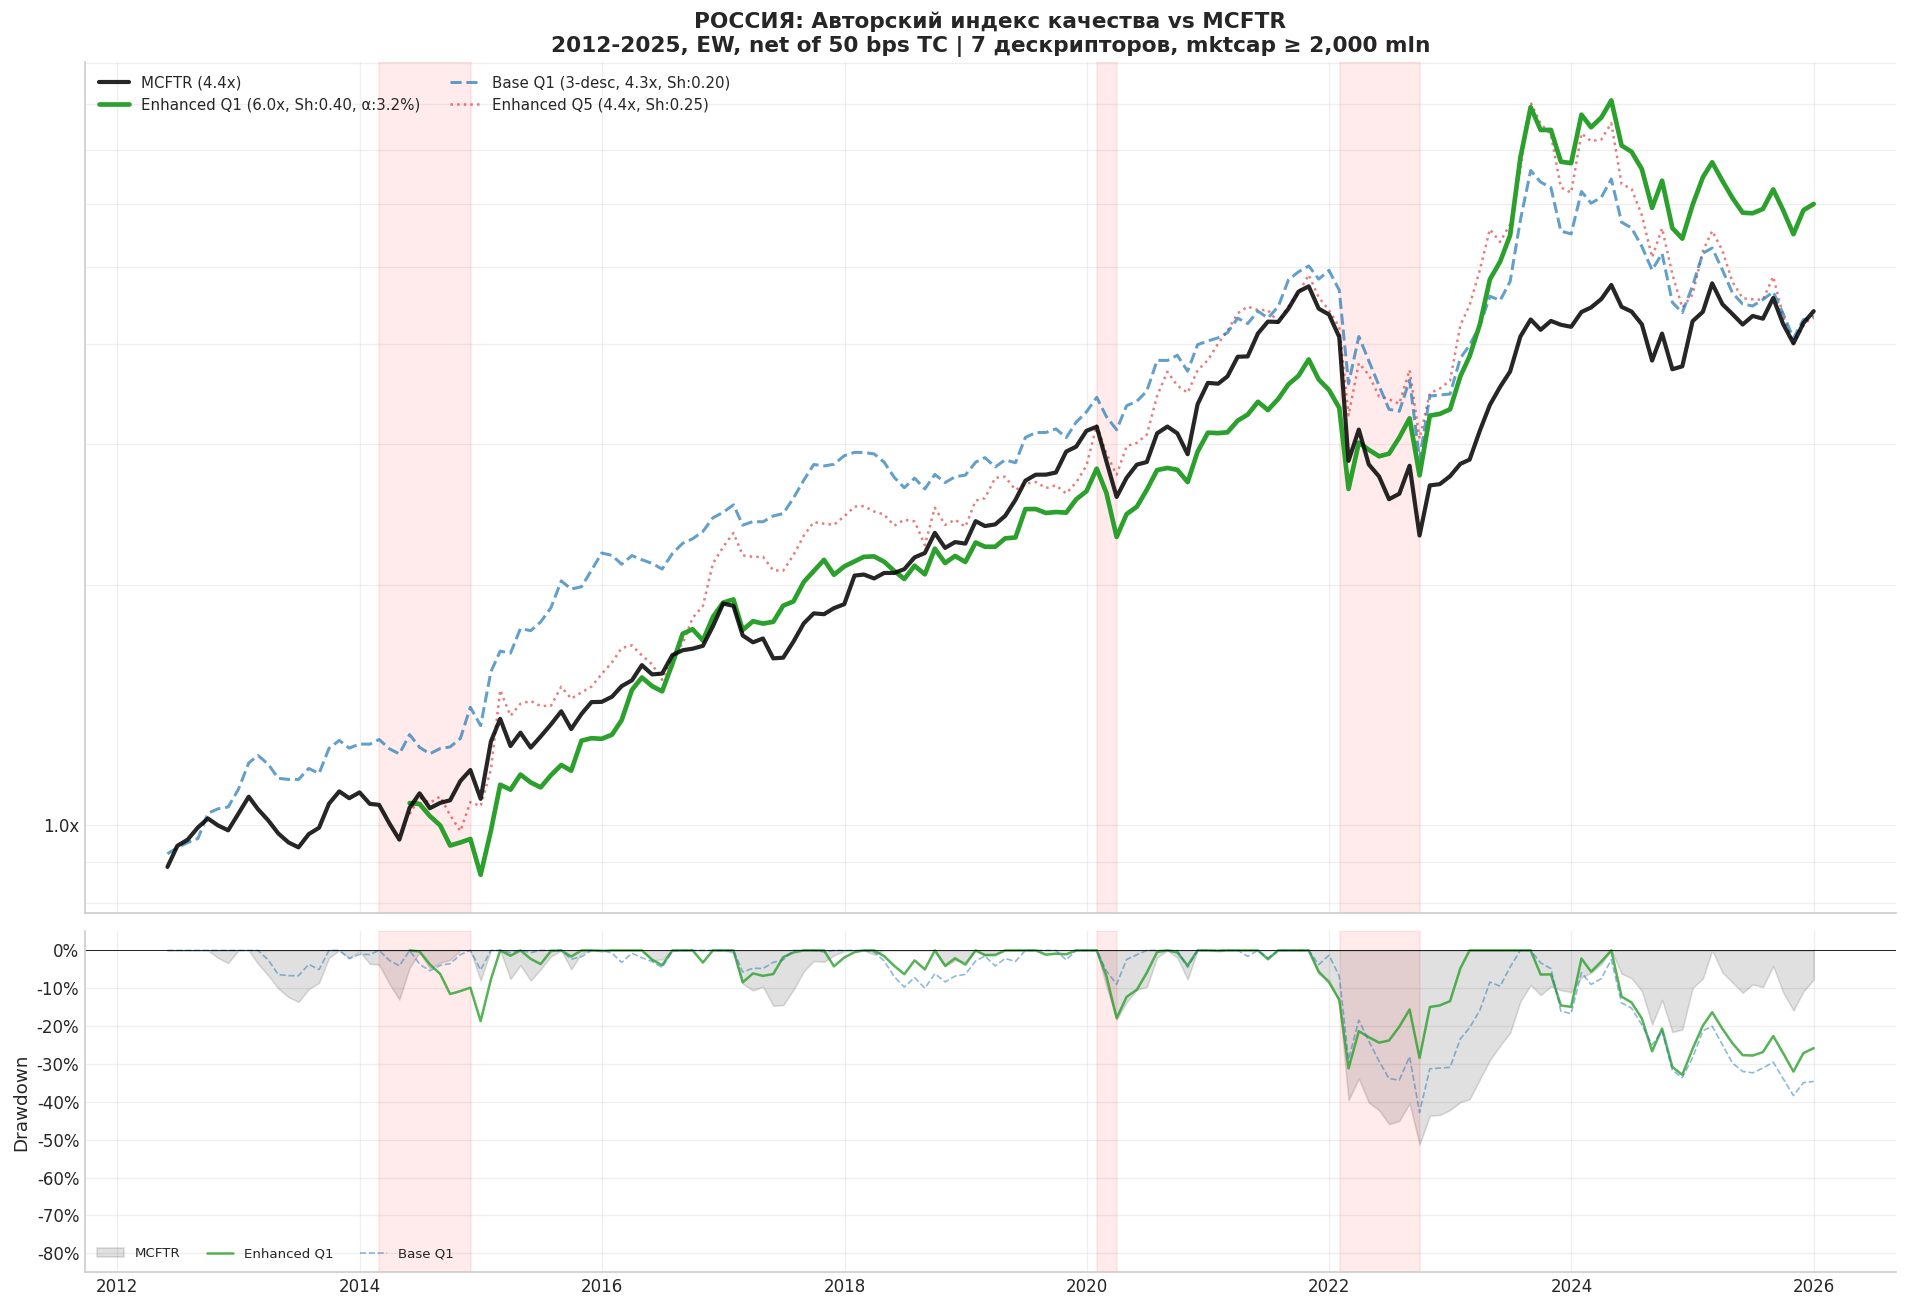

  Saved: /Users/dmitrijeremkin/dividend-factor-strategies/results/quality_barra/enhanced_quality_vs_benchmark_RF.png


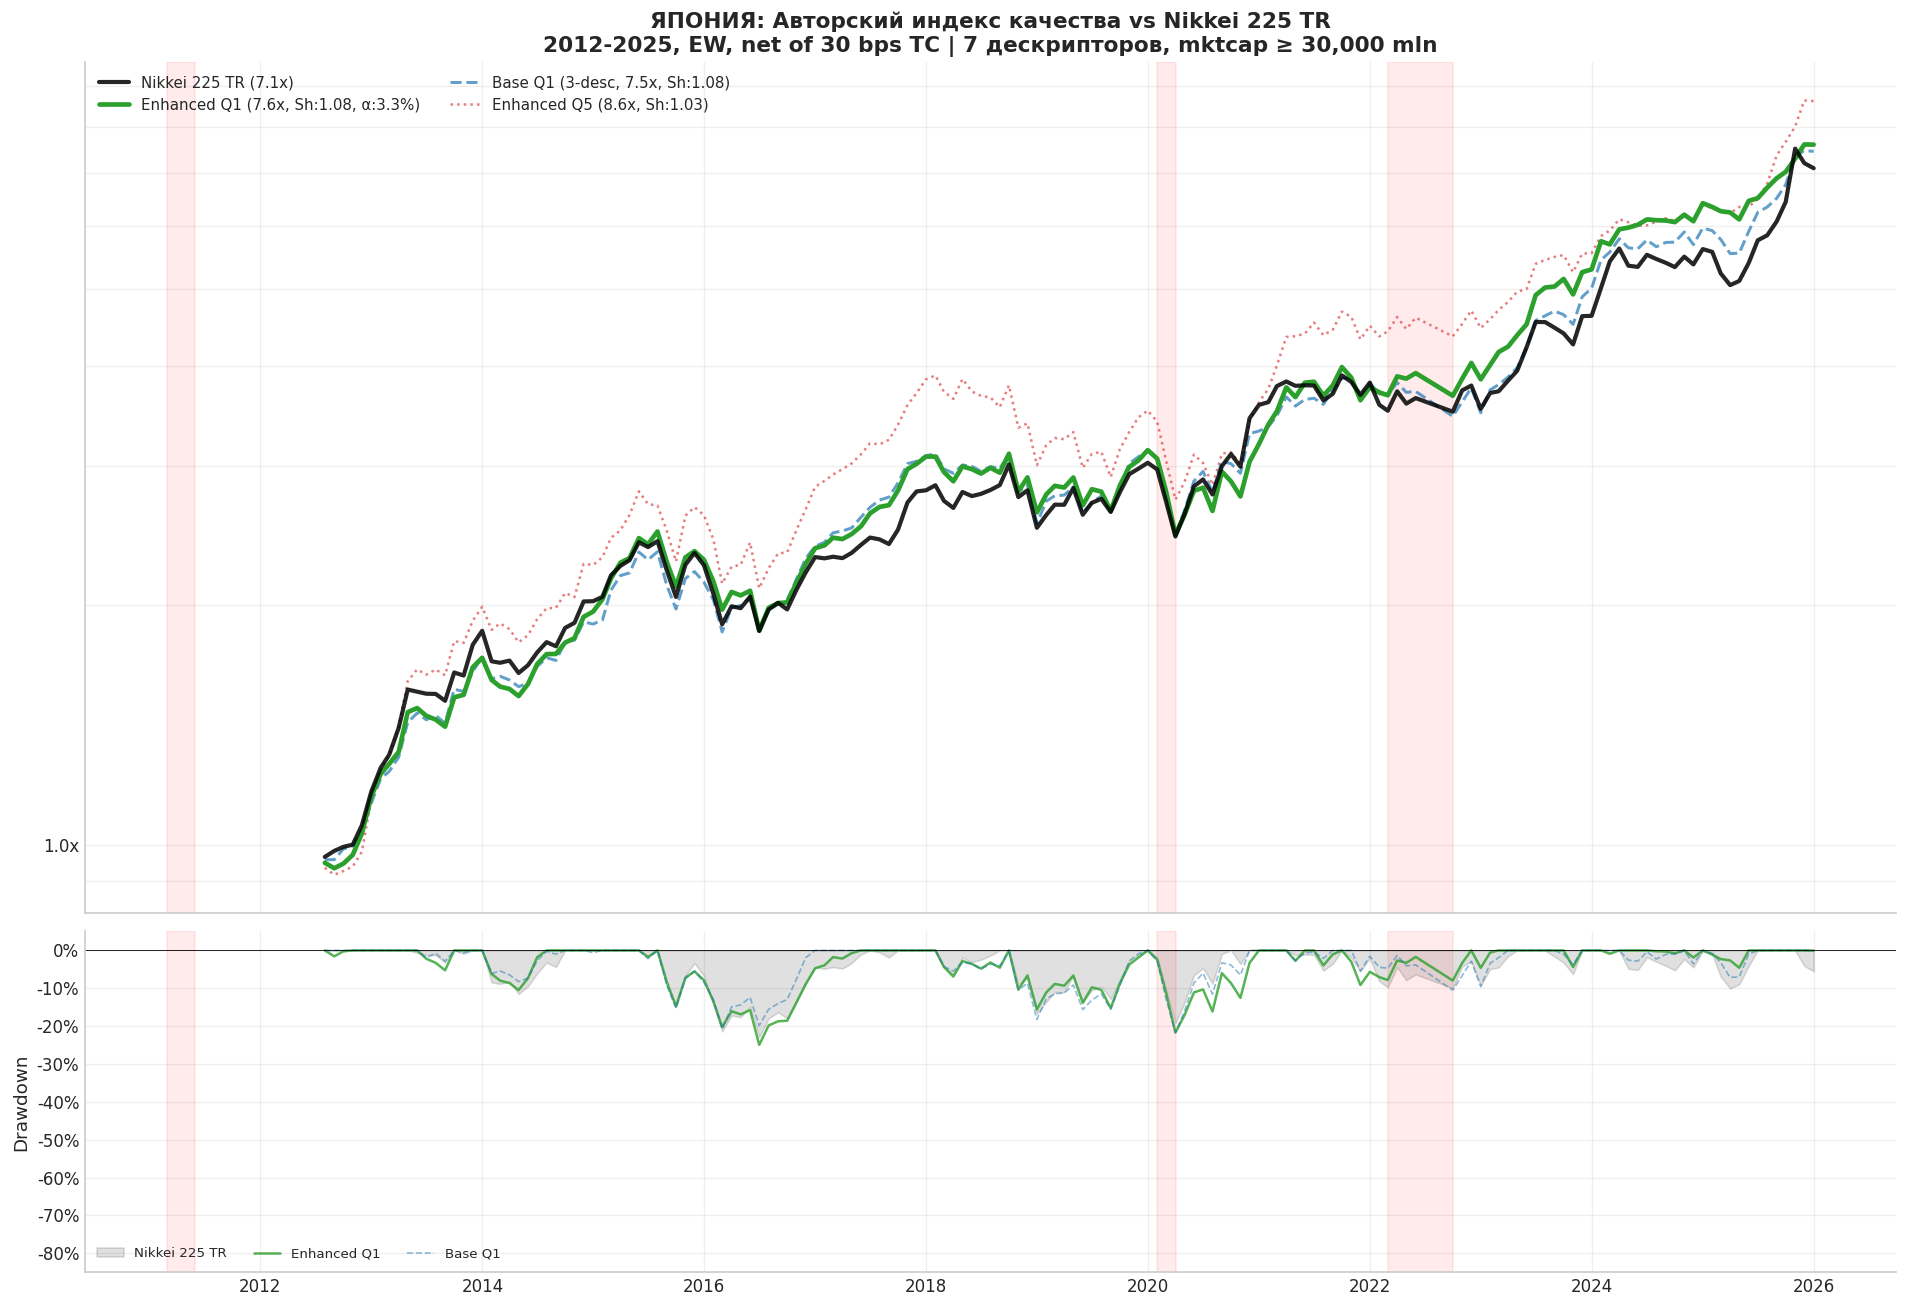

  Saved: /Users/dmitrijeremkin/dividend-factor-strategies/results/quality_barra/enhanced_quality_vs_benchmark_JP.png


In [13]:
# ═══════════════════════════════════════════════════════════
# 8d. АВТОРСКИЙ ИНДЕКС vs БЕНЧМАРК
# ═══════════════════════════════════════════════════════════

for label in ['RF', 'JP']:
    cd = country_data[label]
    dl = cd['dl']
    results_enh = enhanced_data[label]['results']
    enh_cfg = enhanced_data[label]['enh_cfg']
    crises = CRISIS_RF if label == 'RF' else CRISIS_JP
    base_res = cd['results']

    if 1 not in results_enh:
        print(f"  {label}: No Q1 Enhanced results, skipping chart.")
        continue

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 11),
                                    height_ratios=[2.5, 1], sharex=True)

    # ── Временная ось: от первой ребалансировки ──
    forced_start = pd.Timestamp(dl.cfg.start_year, dl.cfg.rebalance_month, 1) \
                   + pd.offsets.MonthEnd(0)
    bm_idx = dl.benchmark.index[dl.benchmark.index >= forced_start]

    # ── Бенчмарк ──
    if len(bm_idx) > 0:
        bm_cum = (1 + dl.benchmark.loc[bm_idx, 'ret']).cumprod()
        ax1.plot(bm_cum.index, bm_cum.values, 'k-', lw=2.5, alpha=0.85,
                 label=f"{dl.cfg.benchmark_name} ({bm_cum.iloc[-1]:.1f}x)",
                 zorder=100)
        bm_dd = bm_cum / bm_cum.cummax() - 1
        ax2.fill_between(bm_dd.index, bm_dd.values, 0, color='black',
                         alpha=0.12, label=dl.cfg.benchmark_name)

    # ── Enhanced Q1 (Авторский индекс) ──
    q1_enh_ret = results_enh[1]['ret'].dropna()
    if len(q1_enh_ret) > 0:
        first_date = q1_enh_ret.index.min()
        bm_sub = bm_idx[bm_idx >= first_date] if len(bm_idx) > 0 else q1_enh_ret.index
        ret_e = q1_enh_ret.reindex(bm_sub).fillna(0)
        cum_e = (1 + ret_e).cumprod()
        dd_e = cum_e / cum_e.cummax() - 1
        m_enh = metrics(q1_enh_ret, dl.rf)
        cap_enh = capm_alpha(q1_enh_ret, dl.benchmark['ret'], dl.rf)

        ax1.plot(cum_e.index, cum_e.values, color='#2ca02c', lw=2.8,
                 label=f"Enhanced Q1 ({cum_e.iloc[-1]:.1f}x, "
                       f"Sh:{m_enh['Sharpe']:.2f}, "
                       f"α:{cap_enh.get('alpha_ann',0):.1%}{cap_enh.get('sig','')})",
                 zorder=90)
        ax2.plot(dd_e.index, dd_e.values, color='#2ca02c', lw=1.5, alpha=0.8,
                 label='Enhanced Q1')

    # ── Base Q1 (базовый Barra 3-descriptor) ──
    if 1 in base_res:
        q1_base_ret = base_res[1]['ret'].dropna()
        if len(q1_base_ret) > 0:
            first_date_b = q1_base_ret.index.min()
            bm_sub_b = bm_idx[bm_idx >= first_date_b] if len(bm_idx) > 0 else q1_base_ret.index
            ret_b = q1_base_ret.reindex(bm_sub_b).fillna(0)
            cum_b = (1 + ret_b).cumprod()
            dd_b = cum_b / cum_b.cummax() - 1
            m_base = metrics(q1_base_ret, dl.rf)

            ax1.plot(cum_b.index, cum_b.values, color='#1f77b4', lw=1.8, ls='--',
                     alpha=0.7,
                     label=f"Base Q1 (3-desc, {cum_b.iloc[-1]:.1f}x, "
                           f"Sh:{m_base['Sharpe']:.2f})",
                     zorder=80)
            ax2.plot(dd_b.index, dd_b.values, color='#1f77b4', lw=1.0, ls='--',
                     alpha=0.5, label='Base Q1')

    # ── Enhanced Q5 (для контраста) ──
    if 5 in results_enh:
        q5_ret = results_enh[5]['ret'].dropna()
        if len(q5_ret) > 0:
            first_q5 = q5_ret.index.min()
            bm_sub_q5 = bm_idx[bm_idx >= first_q5] if len(bm_idx) > 0 else q5_ret.index
            ret_q5 = q5_ret.reindex(bm_sub_q5).fillna(0)
            cum_q5 = (1 + ret_q5).cumprod()
            m_q5 = metrics(q5_ret, dl.rf)
            ax1.plot(cum_q5.index, cum_q5.values, color='#d62728', lw=1.5, ls=':',
                     alpha=0.6,
                     label=f"Enhanced Q5 ({cum_q5.iloc[-1]:.1f}x, "
                           f"Sh:{m_q5['Sharpe']:.2f})")

    # ── Crisis shading ──
    for s, e, n in crises:
        for ax in [ax1, ax2]:
            ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.08, color='red')
        # Аннотация кризиса
        mid = pd.Timestamp(s) + (pd.Timestamp(e) - pd.Timestamp(s)) / 2
        ax1.annotate(n, xy=(mid, ax1.get_ylim()[0]),
                     fontsize=7, ha='center', alpha=0.5, rotation=90, va='bottom')

    # ── Оформление ──
    ax1.set_yscale('log')
    ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x:.1f}x'))
    country_name = 'РОССИЯ' if label == 'RF' else 'ЯПОНИЯ'
    title_line1 = f'{country_name}: Авторский индекс качества vs {dl.cfg.benchmark_name}'
    title_line2 = (f'{dl.cfg.start_year}-{dl.cfg.max_year}, EW, net of {dl.cfg.tc_bps:.0f} bps TC | '
                   f'7 дескрипторов, mktcap ≥ {enh_cfg["min_mktcap"]:,.0f} mln')
    ax1.set_title(f'{title_line1}\n{title_line2}', fontsize=13, fontweight='bold')
    ax1.legend(loc='upper left', fontsize=9, ncol=2, framealpha=0.9)
    ax1.grid(True, alpha=0.3, which='both')
    ax1.tick_params(labelbottom=False)

    ax2.set_ylabel('Drawdown')
    ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x:.0%}'))
    ax2.set_ylim([-0.85, 0.05])
    ax2.grid(True, alpha=0.3)
    ax2.axhline(0, color='black', lw=0.5)
    ax2.legend(loc='lower left', fontsize=8, ncol=3)

    plt.tight_layout()
    fn = os.path.join(OUT, f'enhanced_quality_vs_benchmark_{label}.png')
    plt.savefig(fn, bbox_inches='tight', dpi=180)
    plt.show()
    print(f"  Saved: {fn}")

## 8e. Корреляционная матрица дескрипторов

Проверка информационной неизбыточности 7 дескрипторов расширенной
модели. Корреляция ниже 0.7 означает, что каждый дескриптор вносит
уникальную информацию в композитный скор. Матрица рассчитана на
cross-section последнего полного года данных.

  RF: Max pairwise correlation: 0.56 (AccrualsQuality ↔ CashConversion)
  JP: Max pairwise correlation: 0.69 (FCFYield ↔ CashConversion)


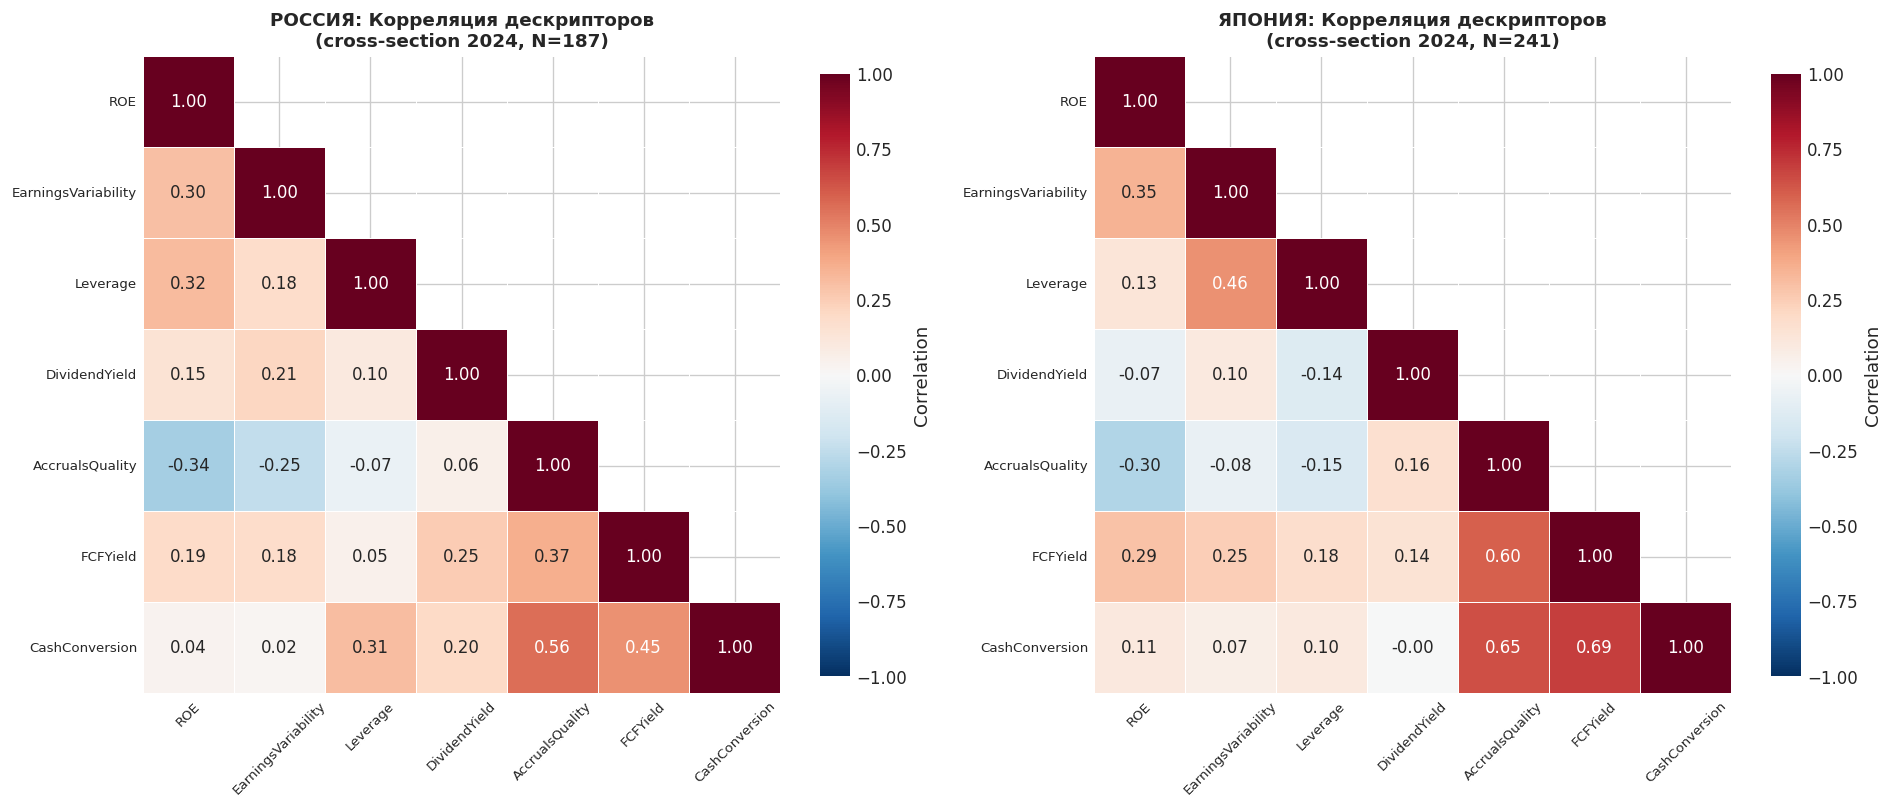

  Saved: /Users/dmitrijeremkin/dividend-factor-strategies/results/quality_barra/descriptor_correlations.png


In [14]:
# ═══════════════════════════════════════════════════════════
# 8e. DESCRIPTOR CORRELATION MATRIX
# ═══════════════════════════════════════════════════════════
# Для каждой страны: берём cross-section последнего полного года,
# вычисляем z-scores по всем 8 дескрипторам и строим корреляционную матрицу.
# Высокая корреляция (>0.7) означает, что дескрипторы дублируют друг друга.
# Умеренная корреляция (0.3-0.5) — желательна: дескрипторы связаны тематически,
# но несут разную информацию.

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for idx, (label, cfg) in enumerate([('RF', cfg_rf), ('JP', cfg_jp)]):
    dl = country_data[label]['dl']
    enh_cfg = ENHANCED_CFG[label]

    # Берём последний полный год данных
    test_year = dl.panel['trading_year'].max() - 1
    uni = dl.panel[dl.panel['trading_year'] == test_year].copy()
    if 'market_cap_mln' in uni.columns:
        uni = uni[uni['market_cap_mln'] >= enh_cfg['min_mktcap']]

    # Вычисляем z-scores всех дескрипторов
    z_data = {}
    for desc_name, desc_cfg in ENHANCED_DESCRIPTORS.items():
        col = None
        for cand in desc_cfg['candidates']:
            if cand in uni.columns and uni[cand].notna().sum() >= 5:
                col = cand; break
        if col is None: continue
        z = zscore(winz(uni[col]))
        z_data[desc_name] = z * desc_cfg['dir']

    if len(z_data) < 4:
        print(f"  {label}: Not enough descriptors for correlation matrix")
        continue

    corr_df = pd.DataFrame(z_data).corr()

    ax = axes[idx]
    mask = np.triu(np.ones_like(corr_df, dtype=bool), k=1)
    sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f', center=0,
                cmap='RdBu_r', vmin=-1, vmax=1, ax=ax,
                square=True, linewidths=0.5,
                cbar_kws={'shrink': 0.8, 'label': 'Correlation'})
    country_name = 'РОССИЯ' if label == 'RF' else 'ЯПОНИЯ'
    ax.set_title(f'{country_name}: Корреляция дескрипторов\n'
                 f'(cross-section {test_year-1}, N={len(uni)})',
                 fontweight='bold', fontsize=11)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)

    # Диагностика: максимальная попарная корреляция
    upper = corr_df.where(np.triu(np.ones_like(corr_df, dtype=bool), k=1))
    max_corr = upper.max().max()
    max_pair = upper.stack().idxmax()
    print(f"  {label}: Max pairwise correlation: {max_corr:.2f} ({max_pair[0]} ↔ {max_pair[1]})")
    if max_corr > 0.7:
        print(f"  WARNING: High correlation >0.7 — consider removing redundant descriptor")

plt.tight_layout()
fn = os.path.join(OUT, 'descriptor_correlations.png')
plt.savefig(fn, bbox_inches='tight', dpi=180); plt.show()
print(f"  Saved: {fn}")

## 8f. Регрессия Фамы–Макбета

Для оценки факторной премии в cross-section доходностей применяется
двухшаговая процедура Fama & MacBeth (1973). На первом шаге для
каждого месяца оценивается поперечная регрессия:

r_{i,t} = γ₀,t + γ₁,t · QualityScore_i + ε_{i,t}

На втором шаге вычисляется среднее коэффициентов γ̄₁ по всем
месяцам. Стандартные ошибки скорректированы по Newey-West
(HAC, 2 лага) для учёта автокорреляции. Три спецификации:
без контролей, с контролем на размер (log market cap) и
с контролем на размер + стоимость (book-to-market).

In [15]:
# ═══════════════════════════════════════════════════════════
# 8f. FAMA-MACBETH REGRESSION
# ═══════════════════════════════════════════════════════════

def fama_macbeth(panel, prices, cfg, score_col='quality_score_enhanced',
                 min_mktcap=None, controls=None):
    """
    Fama-MacBeth cross-sectional regression.

    Каждый месяц: regress ret_i = gamma_0 + gamma_1 * Score_i [+ controls] + eps
    Возвращает: mean gammas, t-stats (Newey-West, 2 lags).
    """
    tc = cfg.ticker_col
    mktcap = min_mktcap or cfg.min_mktcap
    if controls is None:
        controls = []

    gammas_list = []

    for year in range(cfg.start_year, cfg.max_year + 1):
        # Фундаменталы из trading_year
        uni = panel[panel['trading_year'] == year].copy()
        if 'market_cap_mln' in uni.columns and mktcap > 0:
            uni = uni[uni['market_cap_mln'] >= mktcap]
        uni = uni.dropna(subset=[score_col])
        if len(uni) < 20:
            continue

        tickers = uni[tc].unique()

        # Месячные доходности за holding period
        start = pd.Timestamp(year, cfg.rebalance_month, 1)
        for mo in range(12):
            dt = start + pd.DateOffset(months=mo)
            mask = ((prices.index.year == dt.year) &
                    (prices.index.month == dt.month) &
                    prices[tc].isin(tickers))
            md = prices[mask].copy()
            if len(md) < 15:
                continue

            # Merge: return + score
            ticker_ret = md.groupby(tc)['ret'].apply(
                lambda x: (1+x.dropna()).prod()-1 if len(x.dropna())>0 else np.nan
            ).dropna()
            merged = pd.DataFrame({'ret': ticker_ret})
            score_map = uni.set_index(tc)[score_col]
            merged['score'] = merged.index.map(score_map)
            merged = merged.dropna()

            if len(merged) < 15:
                continue

            # Add controls
            X_cols = ['score']
            if 'log_mktcap' in controls and 'market_cap_mln' in uni.columns:
                mktcap_map = uni.set_index(tc)['market_cap_mln'].apply(np.log)
                merged['log_mktcap'] = merged.index.map(mktcap_map)
                X_cols.append('log_mktcap')
            if 'book_to_market' in controls and 'book_to_market' in uni.columns:
                btm_map = uni.set_index(tc)['book_to_market']
                merged['book_to_market'] = merged.index.map(btm_map)
                X_cols.append('book_to_market')

            merged = merged.dropna()
            if len(merged) < 15:
                continue

            # OLS cross-sectional regression
            y = merged['ret'].values
            X = np.column_stack([np.ones(len(merged))] +
                                [merged[c].values for c in X_cols])
            try:
                b = np.linalg.lstsq(X, y, rcond=None)[0]
                gammas = {'const': b[0]}
                for i, c in enumerate(X_cols):
                    gammas[c] = b[i+1]
                gammas['date'] = dt
                gammas['n'] = len(merged)
                gammas_list.append(gammas)
            except:
                continue

    if not gammas_list:
        return None

    gdf = pd.DataFrame(gammas_list).set_index('date')

    # Newey-West t-statistics (2 lags)
    results = {}
    for col in [c for c in gdf.columns if c != 'n']:
        g = gdf[col].dropna()
        if len(g) < 12:
            continue
        mean_g = g.mean()
        T = len(g)
        lags = 2

        # HAC variance
        demeaned = (g - mean_g).values
        var_nw = np.sum(demeaned**2) / T
        for j in range(1, lags+1):
            w = 1 - j/(lags+1)
            cov_j = np.sum(demeaned[j:] * demeaned[:-j]) / T
            var_nw += 2 * w * cov_j
        se = np.sqrt(var_nw / T)
        t_stat = mean_g / se if se > 1e-12 else 0
        p_val = 2 * (1 - stats.t.cdf(abs(t_stat), T - 1))

        results[col] = {
            'gamma_mean': mean_g,
            'gamma_std': g.std(),
            'se_nw': se,
            't_stat': t_stat,
            'p_val': p_val,
            'sig': sig_stars(p_val),
            'n_months': T,
        }

    return results


print(f"\n{'='*90}")
print(f"  FAMA-MACBETH CROSS-SECTIONAL REGRESSIONS")
print(f"  r_i,t = γ₀ + γ₁·QualityScore_i [+ controls] + ε_i,t")
print(f"  t-statistics: Newey-West HAC (2 lags)")
print(f"{'='*90}")

for label, cfg in [('RF', cfg_rf), ('JP', cfg_jp)]:
    dl = country_data[label]['dl']
    enh_cfg = ENHANCED_CFG[label]

    # Спецификации моделей
    specs = [
        ('(1) Quality only', []),
        ('(2) + Size', ['log_mktcap']),
        ('(3) + Size + Value', ['log_mktcap', 'book_to_market']),
    ]

    print(f"\n  {label}: {enh_cfg.get('label', 'Enhanced Quality')}")
    print(f"  {'Spec':<25} {'γ(Quality)':>12} {'t-stat':>8} {'sig':>4} "
          f"{'γ(Size)':>12} {'t(Size)':>8} {'γ(Value)':>12} {'t(Value)':>8} {'N_mo':>6}")
    print(f"  {'─'*105}")

    for spec_name, controls in specs:
        res = fama_macbeth(
            dl.panel, dl.prices, cfg,
            score_col='quality_score_enhanced',
            min_mktcap=enh_cfg['min_mktcap'],
            controls=controls
        )
        if res is None:
            print(f"  {spec_name:<25} — not enough data")
            continue

        q_res = res.get('score', {})
        sz_res = res.get('log_mktcap', {})
        vl_res = res.get('book_to_market', {})

        q_g = f"{q_res.get('gamma_mean',0)*100:.3f}%" if q_res else '—'
        q_t = f"{q_res.get('t_stat',0):+.2f}" if q_res else '—'
        q_s = q_res.get('sig', '') if q_res else ''
        sz_g = f"{sz_res.get('gamma_mean',0)*100:.3f}%" if sz_res else '—'
        sz_t = f"{sz_res.get('t_stat',0):+.2f}" if sz_res else '—'
        vl_g = f"{vl_res.get('gamma_mean',0)*100:.3f}%" if vl_res else '—'
        vl_t = f"{vl_res.get('t_stat',0):+.2f}" if vl_res else '—'
        n = q_res.get('n_months', 0) if q_res else 0

        print(f"  {spec_name:<25} {q_g:>12} {q_t:>8} {q_s:>4} "
              f"{sz_g:>12} {sz_t:>8} {vl_g:>12} {vl_t:>8} {n:>6}")


  FAMA-MACBETH CROSS-SECTIONAL REGRESSIONS
  r_i,t = γ₀ + γ₁·QualityScore_i [+ controls] + ε_i,t
  t-statistics: Newey-West HAC (2 lags)

  RF: Расширенная модель качества (РФ, 7 дескрипторов)
  Spec                        γ(Quality)   t-stat  sig      γ(Size)  t(Size)     γ(Value) t(Value)   N_mo
  ─────────────────────────────────────────────────────────────────────────────────────────────────────────


  (1) Quality only                0.154%    +0.73                 —        —            —        —    141


  (2) + Size                      0.291%    +1.43           -0.213%    -1.98            —        —    141


  (3) + Size + Value              0.291%    +1.43           -0.213%    -1.98            —        —    141

  JP: Расширенная модель качества (JP, 7 дескрипторов)
  Spec                        γ(Quality)   t-stat  sig      γ(Size)  t(Size)     γ(Value) t(Value)   N_mo
  ─────────────────────────────────────────────────────────────────────────────────────────────────────────


  (1) Quality only               -0.053%    -0.49                 —        —            —        —    163


  (2) + Size                      0.014%    +0.14           -0.217%    -2.91            —        —    163


  (3) + Size + Value              0.034%    +0.34           -0.192%    -3.00       0.034%    +0.15    163


## 8g. Скользящий коэффициент Шарпа

Для оценки стабильности факторной премии во времени рассчитывается
скользящий Sharpe Ratio (окно 24 месяца) для портфеля Q1, базовой
модели и бенчмарка. Если портфель Q1 устойчиво превышает бенчмарк
по данному показателю, это свидетельствует о робастности фактора,
а не о случайном результате одного подпериода.

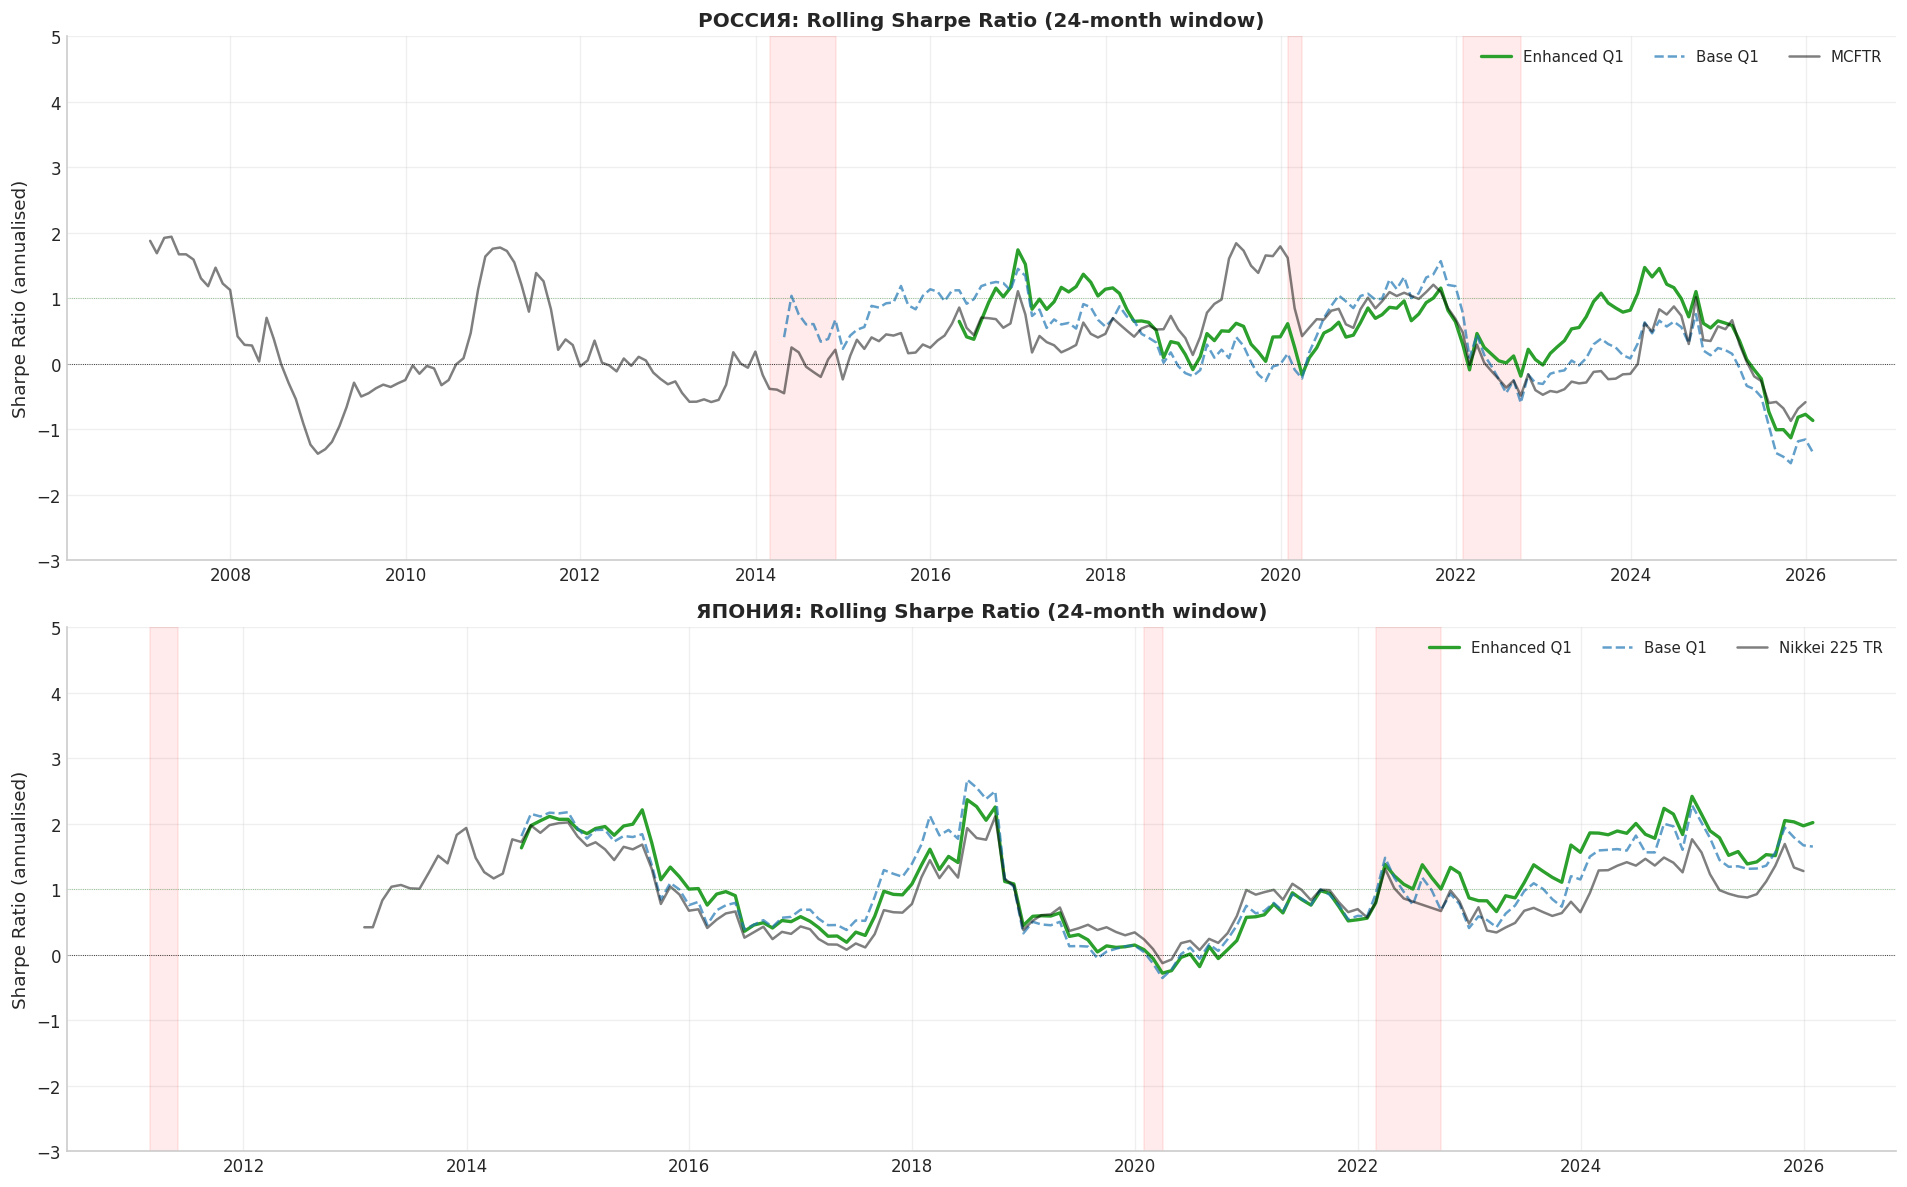

  Saved: /Users/dmitrijeremkin/dividend-factor-strategies/results/quality_barra/rolling_sharpe.png


In [16]:
# ═══════════════════════════════════════════════════════════
# 8g. ROLLING SHARPE (24-MONTH WINDOW)
# ═══════════════════════════════════════════════════════════

ROLL_WINDOW = 24  # месяцев

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=False)

for idx, label in enumerate(['RF', 'JP']):
    ax = axes[idx]
    dl = country_data[label]['dl']
    results_enh = enhanced_data[label]['results']

    # Enhanced Q1
    if 1 in results_enh:
        ret_e = results_enh[1]['ret']
        rf_aligned = dl.rf.reindex(ret_e.index).fillna(dl.rf.mean())
        excess_e = ret_e - rf_aligned
        roll_sh_e = (excess_e.rolling(ROLL_WINDOW).mean() /
                     excess_e.rolling(ROLL_WINDOW).std() * np.sqrt(12))
        ax.plot(roll_sh_e.index, roll_sh_e.values, color='#2ca02c', lw=2,
                label='Enhanced Q1')

    # Base Q1
    base_res = country_data[label]['results']
    if 1 in base_res:
        ret_b = base_res[1]['ret']
        rf_aligned_b = dl.rf.reindex(ret_b.index).fillna(dl.rf.mean())
        excess_b = ret_b - rf_aligned_b
        roll_sh_b = (excess_b.rolling(ROLL_WINDOW).mean() /
                     excess_b.rolling(ROLL_WINDOW).std() * np.sqrt(12))
        ax.plot(roll_sh_b.index, roll_sh_b.values, color='#1f77b4', lw=1.5,
                ls='--', alpha=0.7, label='Base Q1')

    # Benchmark
    bm_ret = dl.benchmark['ret']
    rf_bm = dl.rf.reindex(bm_ret.index).fillna(dl.rf.mean())
    excess_bm = bm_ret - rf_bm
    roll_sh_bm = (excess_bm.rolling(ROLL_WINDOW).mean() /
                  excess_bm.rolling(ROLL_WINDOW).std() * np.sqrt(12))
    ax.plot(roll_sh_bm.index, roll_sh_bm.values, 'k-', lw=1.5, alpha=0.5,
            label=dl.cfg.benchmark_name)

    # Crisis shading
    crises = CRISIS_RF if label == 'RF' else CRISIS_JP
    for s, e, n in crises:
        ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.08, color='red')

    ax.axhline(0, color='black', lw=0.5, ls=':')
    ax.axhline(1.0, color='green', lw=0.5, ls=':', alpha=0.5)
    country_name = 'РОССИЯ' if label == 'RF' else 'ЯПОНИЯ'
    ax.set_title(f'{country_name}: Rolling Sharpe Ratio ({ROLL_WINDOW}-month window)',
                 fontweight='bold', fontsize=12)
    ax.set_ylabel('Sharpe Ratio (annualised)')
    ax.legend(loc='upper right', fontsize=9, ncol=3)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-3, 5])

plt.tight_layout()
fn = os.path.join(OUT, 'rolling_sharpe.png')
plt.savefig(fn, bbox_inches='tight', dpi=180); plt.show()
print(f"  Saved: {fn}")

## 8h. Тест монотонности

Формальная проверка монотонности доходностей квинтилей (Patton &
Timmermann, 2010). Для каждой пары соседних квинтилей (Q_i, Q_{i+1})
вычисляется t-статистика разности средних доходностей. Монотонность
подтверждена, если все попарные разности положительны (Q1 > Q2 > ... > Q5).
Односторонний тест: H₀ — отсутствие монотонного убывания.

In [17]:
# ═══════════════════════════════════════════════════════════
# 8h. MONOTONICITY TEST
# ═══════════════════════════════════════════════════════════
# Упрощённый тест: для каждой пары (Q_i, Q_{i+1}) считаем
# t-stat разности средних доходностей. Монотонность подтверждена,
# если ВСЕ попарные t > 0 (Q_i > Q_{i+1}).

print(f"\n{'='*80}")
print(f"  MONOTONICITY TEST: Pairwise t-statistics (Q_i vs Q_{{i+1}})")
print(f"  H₀: mean(Q_i) ≤ mean(Q_{{i+1}})  |  H₁: mean(Q_i) > mean(Q_{{i+1}})")
print(f"{'='*80}")

for version_name, get_results in [
    ('Base (3 desc)', lambda lb: country_data[lb]['results']),
    ('Enhanced (7 desc)', lambda lb: enhanced_data[lb]['results']),
]:
    print(f"\n  === {version_name} ===")
    for label in ['RF', 'JP']:
        res = get_results(label)
        quintiles = sorted(res.keys())
        if len(quintiles) < 2:
            continue

        print(f"\n  {label}:")
        all_positive = True
        for i in range(len(quintiles) - 1):
            q_hi = quintiles[i]
            q_lo = quintiles[i+1]
            c_idx = res[q_hi].index.intersection(res[q_lo].index)
            if len(c_idx) < 12:
                continue
            diff = res[q_hi]['ret'].loc[c_idx] - res[q_lo]['ret'].loc[c_idx]
            t_stat = diff.mean() / (diff.std() / np.sqrt(len(diff)))
            p_val = 1 - stats.t.cdf(t_stat, len(diff) - 1)  # one-sided
            sig_s = sig_stars(p_val * 2)  # convert to two-sided for stars
            positive = '>' if t_stat > 0 else '<'
            all_positive = all_positive and (t_stat > 0)
            print(f"    Q{q_hi} {positive} Q{q_lo}: "
                  f"diff={diff.mean()*12:.1%}/yr, t={t_stat:+.2f}, "
                  f"p(one-sided)={p_val:.3f} {sig_s}")

        conclusion = 'MONOTONIC' if all_positive else 'NOT MONOTONIC'
        print(f"    → {conclusion}")


  MONOTONICITY TEST: Pairwise t-statistics (Q_i vs Q_{i+1})
  H₀: mean(Q_i) ≤ mean(Q_{i+1})  |  H₁: mean(Q_i) > mean(Q_{i+1})

  === Base (3 desc) ===

  RF:
    Q1 < Q2: diff=-6.3%/yr, t=-1.75, p(one-sided)=0.959 
    Q2 > Q3: diff=8.3%/yr, t=+2.56, p(one-sided)=0.006 **
    Q3 > Q4: diff=2.9%/yr, t=+0.76, p(one-sided)=0.224 
    Q4 < Q5: diff=-3.3%/yr, t=-0.91, p(one-sided)=0.819 
    → NOT MONOTONIC

  JP:
    Q1 < Q2: diff=-0.1%/yr, t=-0.07, p(one-sided)=0.527 
    Q2 > Q3: diff=1.2%/yr, t=+0.84, p(one-sided)=0.202 
    Q3 < Q4: diff=-1.6%/yr, t=-1.06, p(one-sided)=0.854 
    Q4 < Q5: diff=-2.1%/yr, t=-1.12, p(one-sided)=0.867 
    → NOT MONOTONIC

  === Enhanced (7 desc) ===

  RF:
    Q1 > Q2: diff=2.0%/yr, t=+0.62, p(one-sided)=0.270 
    Q2 < Q3: diff=-1.5%/yr, t=-0.46, p(one-sided)=0.677 
    Q3 < Q4: diff=-0.2%/yr, t=-0.05, p(one-sided)=0.521 
    Q4 > Q5: diff=2.4%/yr, t=+0.54, p(one-sided)=0.296 
    → NOT MONOTONIC

  JP:
    Q1 > Q2: diff=0.8%/yr, t=+0.51, p(one-sided)=0

In [18]:
# ═══════════════════════════════════════════════════════════
# 8h. MONOTONICITY TEST
# ═══════════════════════════════════════════════════════════

rows = []
for version_name, get_results in [
    ('Базовая (3 дескр.)', lambda lb: country_data[lb]['results']),
    ('Расширенная (7 дескр.)', lambda lb: enhanced_data[lb]['results']),
]:
    for label in ['RF', 'JP']:
        res = get_results(label)
        quintiles = sorted(res.keys())
        if len(quintiles) < 2:
            continue
        all_positive = True
        for i in range(len(quintiles) - 1):
            q_hi = quintiles[i]
            q_lo = quintiles[i + 1]
            c_idx = res[q_hi].index.intersection(res[q_lo].index)
            if len(c_idx) < 12:
                continue
            diff = res[q_hi]['ret'].loc[c_idx] - res[q_lo]['ret'].loc[c_idx]
            t_stat = diff.mean() / (diff.std() / np.sqrt(len(diff)))
            p_val = 1 - stats.t.cdf(t_stat, len(diff) - 1)
            all_positive = all_positive and (t_stat > 0)
            rows.append({
                'Модель': version_name,
                'Страна': 'Россия' if label == 'RF' else 'Япония',
                'Пара': f'Q{q_hi} − Q{q_lo}',
                'Δr (год.)': diff.mean() * 12,
                't': t_stat,
                'p': p_val,
                'Знач.': sig_stars(p_val * 2),
            })
        rows.append({
            'Модель': version_name,
            'Страна': 'Россия' if label == 'RF' else 'Япония',
            'Пара': 'Монотонность',
            'Δr (год.)': np.nan,
            't': np.nan,
            'p': np.nan,
            'Знач.': 'Да' if all_positive else 'Нет',
        })

mono_df = pd.DataFrame(rows)

def style_mono(styler):
    styler.set_caption('Таблица N. Тест монотонности доходностей квинтилей (попарные t-статистики)')
    styler.hide(axis='index')
    styler.format({
        'Δr (год.)': lambda x: f'{x:.1%}' if pd.notna(x) else '—',
        't': lambda x: f'{x:+.2f}' if pd.notna(x) else '—',
        'p': lambda x: f'{x:.3f}' if pd.notna(x) else '—',
    })
    styler.set_table_styles([
        {'selector': 'caption', 'props': [
            ('font-size', '13px'), ('font-weight', 'bold'),
            ('text-align', 'left'), ('margin-bottom', '8px'), ('color', '#1a1a2e')]},
        {'selector': 'thead th', 'props': [
            ('background-color', '#1a1a2e'), ('color', 'white'),
            ('font-size', '11px'), ('text-align', 'center'),
            ('padding', '6px 10px'), ('border-bottom', '2px solid #e0e0e0')]},
        {'selector': 'td', 'props': [
            ('font-size', '11px'), ('text-align', 'center'),
            ('padding', '5px 10px'), ('border-bottom', '1px solid #eee')]},
        {'selector': 'tr:hover td', 'props': [('background-color', '#f5f5ff')]},
        {'selector': 'table', 'props': [
            ('border-collapse', 'collapse'), ('margin', '0 auto'),
            ('font-family', 'Segoe UI, Arial, sans-serif')]},
    ])
    # Итоговые строки — жирным
    is_total = mono_df['Пара'] == 'Монотонность'
    styler.applymap(lambda _: 'font-weight:bold; background-color:#f0f0f5',
                    subset=pd.IndexSlice[is_total[is_total].index, :])
    # t < 0 красным
    def color_t(val):
        if pd.isna(val): return ''
        return 'color:#c0392b; font-weight:bold' if val < 0 else 'color:#27ae60'
    styler.applymap(color_t, subset=['t'])
    # «Нет» красным, «Да» зелёным
    def color_verdict(val):
        if val == 'Нет': return 'color:#c0392b; font-weight:bold'
        if val == 'Да': return 'color:#27ae60; font-weight:bold'
        return ''
    styler.applymap(color_verdict, subset=['Знач.'])
    return styler

display(mono_df.style.pipe(style_mono))

mono_df.to_excel(os.path.join(OUT, 'monotonicity_test.xlsx'), index=False)
print(f'  Saved: {os.path.join(OUT, "monotonicity_test.xlsx")}')

Модель,Страна,Пара,Δr (год.),t,p,Знач.
Базовая (3 дескр.),Россия,Q1 − Q2,-6.3%,-1.75,0.959,
Базовая (3 дескр.),Россия,Q2 − Q3,8.3%,+2.56,0.006,**
Базовая (3 дескр.),Россия,Q3 − Q4,2.9%,+0.76,0.224,
Базовая (3 дескр.),Россия,Q4 − Q5,-3.3%,-0.91,0.819,
Базовая (3 дескр.),Россия,Монотонность,—,—,—,Нет
Базовая (3 дескр.),Япония,Q1 − Q2,-0.1%,-0.07,0.527,
Базовая (3 дескр.),Япония,Q2 − Q3,1.2%,+0.84,0.202,
Базовая (3 дескр.),Япония,Q3 − Q4,-1.6%,-1.06,0.854,
Базовая (3 дескр.),Япония,Q4 − Q5,-2.1%,-1.12,0.867,
Базовая (3 дескр.),Япония,Монотонность,—,—,—,Нет


  Saved: /Users/dmitrijeremkin/dividend-factor-strategies/results/quality_barra/monotonicity_test.xlsx


## 8i. Ограничения исследования

1. **Survivorship bias.** Вселенная сформирована из текущих составов
   индексов (Nikkei 225, MOEX). Компании, исключённые из индексов
   в течение исследуемого периода, не включены. Bias направлен вверх.

2. **Равновзвешенные портфели.** MSCI Quality Index использует
   взвешивание по капитализации. EW-портфели создают тilt в сторону
   малых компаний, что может генерировать ложную alpha.

3. **Годовая ребалансировка** vs квартальная (MSCI). Более частая
   ребалансировка может улучшить результаты, но повышает TC.

4. **Выбор дескрипторов ex post.** 4 авторских дескриптора добавлены
   после анализа покрытия данных. Смягчение: все 4 имеют
   самостоятельное академическое обоснование (Sloan, 1996 для accruals;
   Novy-Marx, 2013 для profitability и cash flow metrics).

5. **Малая выборка РФ.** 100–180 компаний → 20–36 на квинтиль.
   Для формальных тестов желательно ≥50 на квинтиль.

6. **Структурные шоки в РФ.** Период 2012–2025 включает санкционные
   кризисы (2014, 2022) и COVID (2020). В кризис корреляции стремятся
   к единице, что обнуляет факторный спред.

## 9. Межстрановое сравнение

Прямое сравнение CAGR невозможно (рубль ≠ йена). Используются
только безразмерные метрики: Sharpe Ratio, Sortino, t-статистика
alpha, максимальная просадка. Сравнение выполнено для обеих
спецификаций: базовой (3 дескриптора) и расширенной (7 дескрипторов).

In [19]:
# ═══════════════════════════════════════════════════════════
# 9. CROSS-COUNTRY COMPARISON
# ═══════════════════════════════════════════════════════════

for version_name, get_results in [
    ('Base (3 descriptors)', lambda lb: country_data[lb]['results']),
    ('Enhanced (7 descriptors)', lambda lb: enhanced_data[lb]['results']),
]:
    print(f"\n{'='*90}")
    print(f"  CROSS-COUNTRY: {version_name} — CURRENCY-NEUTRAL METRICS")
    print(f"  CAGR excluded (RUB ≠ JPY); Sharpe & t-stat are dimensionless")
    print(f"{'='*90}")

    print(f"\n  {'Metric':<22} {'RF':>10} {'JP':>10} {'Winner':>8}")
    print(f"  {'─'*55}")

    for pname, q_or_ls in [('Q1 Long Sharpe', 'Q1_sharpe'),
                            ('Q1 Long Sortino', 'Q1_sortino'),
                            ('L/S Sharpe', 'LS_sharpe'),
                            ('Q1 Alpha t-stat', 'Q1_t_alpha'),
                            ('Q1 MaxDD', 'Q1_maxdd'),
                            ('Q1 Hit Rate', 'Q1_hit')]:
        vals = {}
        for lb in ['RF', 'JP']:
            res = get_results(lb)
            dl = country_data[lb]['dl']
            if 'Q1' in q_or_ls and 1 in res:
                m = metrics(res[1]['ret'], dl.rf)
                cap = capm_alpha(res[1]['ret'], dl.benchmark['ret'], dl.rf)
            elif 'LS' in q_or_ls and 1 in res and 5 in res:
                c_idx = res[1].index.intersection(res[5].index)
                ls_r = res[1]['ret'].loc[c_idx] - res[5]['ret'].loc[c_idx]
                m = metrics(ls_r, dl.rf)
                cap = {}
            else:
                vals[lb] = np.nan; continue

            if 'sharpe' in q_or_ls.lower(): vals[lb] = m.get('Sharpe', np.nan)
            elif 'sortino' in q_or_ls.lower(): vals[lb] = m.get('Sortino', np.nan)
            elif 't_alpha' in q_or_ls: vals[lb] = cap.get('t_alpha', np.nan)
            elif 'maxdd' in q_or_ls: vals[lb] = m.get('MaxDD', np.nan)
            elif 'hit' in q_or_ls: vals[lb] = m.get('HitRate', np.nan)

        rf_v = vals.get('RF', np.nan); jp_v = vals.get('JP', np.nan)
        if 'maxdd' in q_or_ls:
            winner = 'RF' if rf_v > jp_v else 'JP'
            fmt = '.1%'
        elif 'hit' in q_or_ls:
            winner = 'RF' if rf_v > jp_v else 'JP'
            fmt = '.0%'
        else:
            winner = 'RF' if rf_v > jp_v else 'JP'
            fmt = '.2f'
        print(f"  {pname:<22} {rf_v:>10{fmt}} {jp_v:>10{fmt}} {winner:>8}")


  CROSS-COUNTRY: Base (3 descriptors) — CURRENCY-NEUTRAL METRICS
  CAGR excluded (RUB ≠ JPY); Sharpe & t-stat are dimensionless

  Metric                         RF         JP   Winner
  ───────────────────────────────────────────────────────
  Q1 Long Sharpe               0.20       1.08       JP
  Q1 Long Sortino              0.02       0.13       JP
  L/S Sharpe                  -0.56      -0.30       JP
  Q1 Alpha t-stat              0.16       1.56       JP
  Q1 MaxDD                   -42.8%     -21.7%       JP
  Q1 Hit Rate                   60%        69%       JP

  CROSS-COUNTRY: Enhanced (7 descriptors) — CURRENCY-NEUTRAL METRICS
  CAGR excluded (RUB ≠ JPY); Sharpe & t-stat are dimensionless

  Metric                         RF         JP   Winner
  ───────────────────────────────────────────────────────
  Q1 Long Sharpe               0.40       1.08       JP
  Q1 Long Sortino              0.05       0.13       JP
  L/S Sharpe                  -0.54      -0.16       JP
  Q1

## 10. Робастность по подпериодам

Разбиение на два подпериода (2012–2018 и 2019–2025) позволяет оценить
устойчивость результатов. Для РФ второй подпериод включает
санкционные шоки 2022 г., что создаёт дополнительный stress-test.

In [20]:
# ═══════════════════════════════════════════════════════════
# 10. SUBPERIOD ROBUSTNESS (2012-2018 vs 2019-2025)
# ═══════════════════════════════════════════════════════════

split = pd.Timestamp('2019-01-01')

rows = []
for version_name, get_results in [
    ('Базовая (3 дескр.)', lambda lb: country_data[lb]['results']),
    ('Расширенная (7 дескр.)', lambda lb: enhanced_data[lb]['results']),
]:
    for label in ['RF', 'JP']:
        dl = country_data[label]['dl']
        res = get_results(label)
        if 1 not in res:
            continue
        ret = res[1]['ret']
        rf_s = dl.rf.reindex(ret.index).fillna(dl.rf.mean())
        for pname, pmask in [('Полный период', ret.index >= ret.index.min()),
                             ('2012–2018', ret.index < split),
                             ('2019–2025', ret.index >= split)]:
            r_sub = ret[pmask]
            if len(r_sub) < 12:
                continue
            m = metrics(r_sub, rf_s[pmask])
            rows.append({
                'Модель': version_name,
                'Страна': 'Россия' if label == 'RF' else 'Япония',
                'Период': pname,
                'CAGR': m['CAGR'],
                'Sharpe': m['Sharpe'],
                'Sortino': m.get('Sortino', np.nan),
                'MaxDD': m['MaxDD'],
                'Vol': m['Vol'],
                'N мес.': m['N_months'],
            })

sub_df = pd.DataFrame(rows)

def style_subperiod(styler):
    styler.set_caption('Таблица N. Робастность портфеля Q1 по подпериодам')
    styler.hide(axis='index')
    styler.format({
        'CAGR': '{:.1%}', 'Sharpe': '{:+.2f}', 'Sortino': '{:+.2f}',
        'MaxDD': '{:.1%}', 'Vol': '{:.1%}', 'N мес.': '{:.0f}',
    })
    styler.set_table_styles([
        {'selector': 'caption', 'props': [
            ('font-size', '13px'), ('font-weight', 'bold'),
            ('text-align', 'left'), ('margin-bottom', '8px'), ('color', '#1a1a2e')]},
        {'selector': 'thead th', 'props': [
            ('background-color', '#1a1a2e'), ('color', 'white'),
            ('font-size', '11px'), ('text-align', 'center'),
            ('padding', '6px 10px'), ('border-bottom', '2px solid #e0e0e0')]},
        {'selector': 'td', 'props': [
            ('font-size', '11px'), ('text-align', 'center'),
            ('padding', '5px 10px'), ('border-bottom', '1px solid #eee')]},
        {'selector': 'tr:hover td', 'props': [('background-color', '#f5f5ff')]},
        {'selector': 'table', 'props': [
            ('border-collapse', 'collapse'), ('margin', '0 auto'),
            ('font-family', 'Segoe UI, Arial, sans-serif')]},
    ])
    # Полный период — жирным фоном
    is_full = sub_df['Период'] == 'Полный период'
    styler.applymap(lambda _: 'font-weight:bold; background-color:#f0f0f5',
                    subset=pd.IndexSlice[is_full[is_full].index, :])
    # Sharpe: зелёный > 0.5, оранжевый 0–0.5, красный < 0
    def color_sharpe(val):
        if pd.isna(val): return ''
        if val >= 0.5: return 'color:#27ae60; font-weight:bold'
        if val >= 0: return 'color:#e67e22'
        return 'color:#c0392b; font-weight:bold'
    styler.applymap(color_sharpe, subset=['Sharpe'])
    # MaxDD: чем глубже, тем краснее
    def color_dd(val):
        if pd.isna(val): return ''
        if val > -0.20: return 'color:#27ae60'
        if val > -0.40: return 'color:#e67e22'
        return 'color:#c0392b; font-weight:bold'
    styler.applymap(color_dd, subset=['MaxDD'])
    return styler

display(sub_df.style.pipe(style_subperiod))

sub_df.to_excel(os.path.join(OUT, 'subperiod_robustness.xlsx'), index=False)
print(f'  Saved: {os.path.join(OUT, "subperiod_robustness.xlsx")}')

Модель,Страна,Период,CAGR,Sharpe,Sortino,MaxDD,Vol,N мес.
Базовая (3 дескр.),Россия,Полный период,11.8%,+0.20,+0.02,-42.8%,20.3%,165
Базовая (3 дескр.),Россия,2012–2018,16.4%,+0.59,+0.10,-10.0%,13.2%,80
Базовая (3 дескр.),Россия,2019–2025,7.7%,+0.03,+0.00,-42.8%,25.2%,85
Базовая (3 дескр.),Япония,Полный период,16.7%,+1.08,+0.13,-21.7%,15.5%,163
Базовая (3 дескр.),Япония,2012–2018,15.4%,+1.00,+0.11,-20.7%,15.7%,78
Базовая (3 дескр.),Япония,2019–2025,18.0%,+1.15,+0.15,-21.7%,15.5%,85
Расширенная (7 дескр.),Россия,Полный период,17.5%,+0.40,+0.05,-32.9%,22.6%,141
Расширенная (7 дескр.),Россия,2012–2018,17.7%,+0.51,+0.08,-18.7%,16.5%,56
Расширенная (7 дескр.),Россия,2019–2025,17.5%,+0.36,+0.05,-32.9%,25.9%,85
Расширенная (7 дескр.),Япония,Полный период,16.9%,+1.08,+0.13,-25.0%,15.7%,163


  Saved: /Users/dmitrijeremkin/dividend-factor-strategies/results/quality_barra/subperiod_robustness.xlsx


## 11. Экспорт результатов

In [21]:
# ═══════════════════════════════════════════════════════════
# 11. EXPORT TO EXCEL
# ═══════════════════════════════════════════════════════════

export_path = os.path.join(OUT, 'barra_quality_results.xlsx')
with pd.ExcelWriter(export_path, engine='openpyxl') as w:
    for label in ['RF', 'JP']:
        cd = country_data[label]; dl = cd['dl']

        # Base quintiles
        res = cd['results']
        rows = []
        for q in sorted(res):
            m = metrics(res[q]['ret'], dl.rf)
            cap = capm_alpha(res[q]['ret'], dl.benchmark['ret'], dl.rf)
            te = tracking_error(res[q]['ret'], dl.benchmark['ret'])
            row = {'Quintile': f'Q{q}', 'Version': 'Base', **m, 'TE': te}
            row.update({f'alpha_{k}': v for k, v in cap.items()})
            rows.append(row)

        # Enhanced quintiles
        res_enh = enhanced_data[label]['results']
        for q in sorted(res_enh):
            m = metrics(res_enh[q]['ret'], dl.rf)
            cap = capm_alpha(res_enh[q]['ret'], dl.benchmark['ret'], dl.rf)
            te = tracking_error(res_enh[q]['ret'], dl.benchmark['ret'])
            row = {'Quintile': f'Q{q}', 'Version': 'Enhanced', **m, 'TE': te}
            row.update({f'alpha_{k}': v for k, v in cap.items()})
            rows.append(row)

        pd.DataFrame(rows).to_excel(w, f'{label}_quintiles', index=False)

        # Quality scores per year (base + enhanced)
        score_cols = ['trading_year', dl.cfg.ticker_col]
        if 'quality_score' in dl.panel.columns:
            score_cols.append('quality_score')
        if 'quality_score_enhanced' in dl.panel.columns:
            score_cols.append('quality_score_enhanced')
        qs = dl.panel[score_cols].dropna(subset=score_cols[2:], how='all')
        qs.to_excel(w, f'{label}_scores', index=False)

print(f"  Exported: {export_path}")
print("\n  Done.")

  Exported: /Users/dmitrijeremkin/dividend-factor-strategies/results/quality_barra/barra_quality_results.xlsx

  Done.
